# 📊 Gehaltsprognose & Interpretation für IT & Data-Berufe  
### (Machine Learning Projekt)

---

### 📌 Projekt-Metadaten

* **Datenquelle:** [Stack Overflow Developer Survey](https://survey.stackoverflow.co/)
* **Untersuchungszeitraum:** 2020–2025
* **Datensatzgröße** ~198 600 Datensätze aus 180+ Ländern

---

### 🔍 Kurzbeschreibung

Dieses Projekt entwickelt eine vollständige End-to-End-Pipeline zur **Vorhersage und Interpretation von Gehältern** auf dem internationalen Markt für Data-Berufe.

Auf Basis von Stack Overflow Developer Surveys (2020–2025) wird ein robustes Regressionsmodell trainiert, das Gehälter in Abhängigkeit von Land, Rolle, Erfahrung, Bildungsabschluss und technischen Skills vorhersagt. SHAP-Analysen sorgen für vollständige Transparenz (White-Box-Ansatz) und isolieren den wirtschaftlichen Effekt einzelner Skills.

Das Endergebnis ist ein interaktives **Data Career Advisor**-System, das personalisierte Gehaltsschätzungen und Skill-Empfehlungen mit quantifizierbarem Einkommenspotenzial liefert.

---

### 📘 Projektstruktur
1. Bibliotheksimport, Datenladen und allgemeine Datenstrukturen
2. EDA + Idee für Features Engineering  
3. Base Model 
4. Train-Test-Split
5. Machine Learning 
6. SHAP-Analyse & Modellinterpretation
7. Data Career Advisor — Empfehlungssystem
8. Fazit

---

### 🛠️ Technologie-Stack

`Python` · `CatBoost` · `Optuna` · `SHAP` · `scikit-learn` · `Pandas` · `Matplotlib` · `Seaborn`

---

### ✨ Wichtigste Ergebnisse

* **Bestes Modell** CatBoostRegressor (Optuna-optimiert)
* **MAE** ~$25 300 / Jahr 
* **R²**  0.62 

---

---
## 📦 1. Bibliotheksimport, Datenladen und allgemeine Datenstrukturen

📗 Import von externen Bibliotheken und Modulen

In [1]:
# 1. Systemabhängigkeiten (Prozessmanagement, Warnungsfilterung)
import importlib
import os
import re
import warnings
from itertools import product as iterproduct
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

# 2. Datenanalyse-Tools
import numpy as np
import pandas as pd

# 3. Visualisierungsbibliotheken
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# 4. Machine learning
# 4.1. Pipelines und Architektur
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

# 4.2. Textvorverarbeitung, Imputation und Vektorisierung
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, MultiLabelBinarizer, OneHotEncoder, StandardScaler

# 4.3.Validierung, Clustering und Dekomposition
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

# 4.4. Basis- und lineare Modelle, Klassifikatoren
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor, StackingRegressor, GradientBoostingRegressor

# 4.5. Gradient Boosting
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# 4.6. Hyperparameter-Optimierung und Modellinterpretierbarkeit
import optuna
import shap
from optuna.samplers import TPESampler
from collections import Counter

# 5. Visualisierung
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


📙 Import lokaler Projektmodule

In [2]:
# Modulimporte 
import config_mappings as cfg
import utils
import advisor

# Hot-Reload: Module werden bei Quelltextänderungen automatisch neu geladen
importlib.reload(utils)
importlib.reload(cfg)
importlib.reload(advisor)

# Explizite Importe aus utils
# Datenladen & Normalisierung
from utils import (load_year,
                   normalize_year)

# Datenbereinigung & Feature Engineering
from utils import (overview,
                   drop_columns,
                   optimize_types,
                   fix_apostrophes,
                   impute_work_exp,
                   merge_feature_cols,
                   normalize_multivalue_column,
                   replace_rare_with_other,
                   clean_employment_status,
                   categorize_currency,
                   categorize_age,
                   group_rare_categories)

# Rollenklassifizierung
from utils import (classify_data_role,
                   enrich_devtype_features,
                   compute_sample_weights,
                   generate_skill_meta)

# EDA — Analyse & Visualisierung
from utils import (explore_unique_values,
                   explore_multivalue_column,
                   eda_categorical,
                   eda_numeric,
                   eda_numeric_bins)

# Modellierung & Evaluation
from utils import (data_split,
                   result)

# SHAP — Interpretierbarkeit
from utils import shap_log_to_usd_skill

# Explizite Importe aus advisor
from advisor import DataCareerAdvisor

🎨 Globale Visualisierung und Anpassung der Farbpalette

In [3]:
# Erzeugung der gemischten 'tab20'-Palette
# Fixierung des 'seed' zur Gewährleistung der Reproduzierbarkeit der Farbanordnung
base_colors = list(sns.color_palette('tab20', 20).as_hex())
rng = np.random.default_rng(seed=4)
rng.shuffle(base_colors)

# Globale Registrierung der Palette in Seaborn
# Definition der benutzerdefinierten Farbpalette als Standard für alle nachfolgenden Grafiken.
sns.set_palette(sns.color_palette(base_colors))

# Definition von Farb-Konstanten für den manuellen Zugriff
COLORS = base_colors
C_BLUE, C_RED, C_GREEN = COLORS[0], COLORS[1], COLORS[2]

# Konfiguration der globalen Stileinstellungen (RcParams)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFBFB",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.color": "#EAEAEA",
    "grid.alpha": 0.8,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
    "savefig.bbox": "tight"
})

print("✔️ Erfolgreiche Aktivierung von Stil für das gesamte Notebook.")

✔️ Erfolgreiche Aktivierung von Stil für das gesamte Notebook.


📂 Historische Daten laden und Funktionsumfang prüfen

In [4]:
# 1. Sequenzielles Laden und Zusammenführen von Daten

# Puffer zum Sammeln verarbeiteter Datenrahmen
frames, loaded, missing = [], [], []

# Iteration über das Forschungszeitintervall
for year in list(range(2020, 2026)):
    # Laden des Rohdatenrahmens und des Dateinamens aus dem lokalen Verzeichnis „data“
    df_raw, fname = load_year(year, 'data')

    # Schutz vor fehlenden Dateien
    if df_raw is None:
        print(f"  ❌ {year}: Datei nicht gefunden")
        missing.append(year)
        continue

    # Standardisierung von Spaltennamen und Datentypen gemäß dem Konfigurationsschema
    df_norm = normalize_year(df_raw, year, cfg.schema)
    
    # Anzahl der ausgefüllten Fragebögen mit Zielvariable (Gehalt)
    n_salary = df_norm['salary'].notna().sum()
    
    # Speichern des gelöschten Datenrahmens im Puffer
    frames.append(df_norm)
    loaded.append(year)
    
    # Zeigt ein detailliertes Protokoll der Downloads des laufenden Jahres an
    print(f"✔️ {year}  [{fname:18s}]  {len(df_raw):>7,} Zeilen salary={n_salary:>7,}")

# Abschließende Zusammenführung aller Dateien
df = pd.concat(frames, ignore_index=True)

# 2. Erstellung und Analyse einer Feature-Abdeckungskarte (Feature Coverage Map)

print("\n" + "="*60 + " Feature Coverage Map " + "="*60)

# Hervorhebung nur der wichtigsten Merkmale
feature_cols = [c for c in df.columns if c != 'year']
coverage_records = []

# Überprüfung des Vorhandenseins und der Vollständigkeit der Features für jedes erfolgreich geladene Jahr
for year in sorted(loaded):
    df_yr = df[df['year'] == year]
    row = {'Год': year}
    
    for c in feature_cols:
        # Ein Feature gilt als verfügbar (+), wenn die Spalte existiert und mehr als nur NaN-Werte enthält
        has_data = c in df_yr.columns and df_yr[c].notna().any()
        row[c] = '+' if has_data else '-'
        
    coverage_records.append(row)

# Das Ergebnis ist ein lesbarer DataFrame
df_coverage = pd.DataFrame(coverage_records).set_index('Год')

# Ausgabe der Abdeckungsmatrix
print(df_coverage.to_string())

✔️ 2020  [so_2020.csv       ]   64,461 Zeilen salary= 34,756
✔️ 2021  [so_2021.csv       ]   83,439 Zeilen salary= 46,844
✔️ 2022  [so_2022.csv       ]   73,268 Zeilen salary= 38,071
✔️ 2023  [so_2023.csv       ]   89,184 Zeilen salary= 48,019
✔️ 2024  [so_2024.csv       ]   65,437 Zeilen salary= 23,435
✔️ 2025  [so_2025.csv       ]   49,191 Zeilen salary= 23,947

============================================================ Feature Coverage Map ============================================================
     salary currency country age workexp yearscode yearscodepro remote branch devtype education employment industry orgsize icorpm language_have language_entry database_have database_entry platform_have platform_entry webframe_have webframe_entry tech_have tech_entry ai_have ai_entry aiselect aiagents activities opsys office_stack
Год                                                                                                                                                          

In [5]:
df = merge_feature_cols(df, 'language_have', 'language_entry', 'language')
df = merge_feature_cols(df, 'database_have', 'database_entry', 'database')
df = merge_feature_cols(df, 'platform_have', 'platform_entry', 'platform')
df = merge_feature_cols(df, 'webframe_have', 'webframe_entry', 'webframe')
df = merge_feature_cols(df, 'tech_have', 'tech_entry', 'tech')
df = merge_feature_cols(df, 'ai_have', 'ai_entry', 'ai')
df = drop_columns(df, ['language_have', 'language_entry', 'database_have', 'database_entry', 'platform_have', 'platform_entry', 'webframe_have', 'webframe_entry', 
                       'tech_have', 'tech_entry', 'ai_have', 'ai_entry'])

🛠️ Auf Duplikate prüfen

In [6]:
# Auf Duplikate prüfen
print(f"📝 Anzahl der Duplikate: {df.duplicated().sum()}")

if df.duplicated().sum()>0:
    df = df.drop_duplicates(keep='first')
    print(f"✔️ Duplikate entfernt")

📝 Anzahl der Duplikate: 10489
✔️ Duplikate entfernt


🧹 Normalisierung von Lückenmustern in Zeichenketten und Behandlung von Textanomalien

In [7]:
# Liste der String-Variationen mit Lücken
nan_variants = ["NaN", "nan", "<NA>", "<na>", "None", "none", "null", ""]

# Spalten nach Datentyp trennen
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Vereinheitlichung kategorischer Auslassungen ('Unknown')
df[cat_cols] = df[cat_cols].map(lambda x: ('Unknown' if pd.isna(x) or str(x).strip() in nan_variants or x is None else x))

# Datenbereinigung der Berufserfahrung (`workexp`, `yearscode`)
df['workexp'] = df['workexp'].replace({'Unknown': np.nan}).astype(float)
df['yearscode'] = df['yearscode'].replace({'Less than 1 year': 0, 'More than 50 years': 51, 'Unknown': np.nan}).astype(float)
df['yearscodepro'] = df['yearscodepro'].replace({'Less than 1 year': 0, 'More than 50 years': 51, 'Unknown': np.nan}).astype(float)
df['age'] = df['age'].apply(categorize_age)

# Replace der Land
df['country'] = df['country'].replace({'United States of America': 'United States', 'United Kingdom of Great Britain and Northern Ireland': 'Great Britain'})
# Region
df['country_region'] = (df['country'].map(cfg.region_mapping).fillna('Other')) 

print(f"✔️ Verarbeitung abgeschlossen")

✔️ Verarbeitung abgeschlossen


🗂️ Normalisierung

In [8]:
df = enrich_devtype_features(df, devtype_col='devtype')

df = normalize_multivalue_column(df, 'devtype', mapping=cfg.role_category_mapping)

df["primary_role"] = (df["devtype"].str.split(";").str[0].str.strip())

# Anreicherung der Merkmale aus 'devtype'


In [9]:
df = normalize_multivalue_column(df, "devtype_data", mapping=cfg.role_category_mapping)
df = normalize_multivalue_column(df, "devtype_other", mapping=cfg.role_category_mapping)

In [10]:
explore_multivalue_column(df, 'devtype_data', top_n=100)
explore_multivalue_column(df, 'devtype_other', top_n=100)

🔍 Spaltenanalyse: 'devtype_data'
Zeilen: 414,491     Ausgefüllt (Nicht-NaN): 414,491     Eindeutige Werte: 30
Anzeige der ersten 6 Zeilen:
                                Häufigkeit  Anteil (%)
devtype_data                                          
None                                367998       88.78
Database Administrator               16913        4.08
Data Scientist / ML specialist       14871        3.59
Data Engineer                        14650        3.53
Data/Financial Analyst               12821        3.09
Data Science & AI                     1456        0.35
------------------------------------------------------------

🔍 Spaltenanalyse: 'devtype_other'
Zeilen: 414,491     Ausgefüllt (Nicht-NaN): 414,491     Eindeutige Werte: 2,041
Anzeige der ersten 12 Zeilen:
                                     Häufigkeit  Anteil (%)
devtype_other                                              
Developer Software Engineering           262771       63.40
None                               

✂️ Ausreißerfilterung (IQR-Methode)

In [11]:
# Entfernung von NaN-Werten in der Zielvariable
df = df.dropna(subset=['salary']).copy()

# Berechnung von Quantilen und Interquartilsabstand (IQR)
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

# Adaptive Obergrenze und feste Untergrenze
upper_bound = Q3 + 3.0 * IQR
lower_bound = 5000  # Bedingtes Null-Einkommen

print(f"📐 Die Grenzen für angemessene Gehälter wurden definiert: von ${lower_bound:,} bis ${upper_bound:,.0f}")

# Filtern des Datenrahmens, Entfernen von Anomalien
df = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)].copy()
df['salary'] = df['salary'] / 1000

📐 Die Grenzen für angemessene Gehälter wurden definiert: von $5,000 bis $343,687


📊 Datenstruktur

In [12]:
print(f"✏️ Datensatzdimension: {df.shape}")

✏️ Datensatzdimension: (198628, 33)


In [13]:
# Transponierte Ausgabe der ersten 5 Zeilen des Dataframes
df.head().T

,7,9,10,11,12
year,2020,2020,2020,2020,2020
salary,116.0,32.315,40.07,14.268,38.916
currency,United States dollar,Pound sterling,Pound sterling,European Euro,European Euro
country,United States,United Kingdom,United Kingdom,Spain,Netherlands
age,35-44,18-24,18-24,45-54,45-54
workexp,NaN,NaN,NaN,NaN,NaN
yearscode,17.0,8.0,10.0,7.0,35.0
yearscodepro,13.0,4.0,2.0,7.0,20.0
remote,Unknown,Unknown,Unknown,Unknown,Unknown
branch,I am a developer by profession,I am a developer by profession,I am a developer by profession,I am a developer by profession,"I am not primarily a developer, but I write co..."


In [14]:
# Allgemeiner Überblick über die Datenstruktur
overview(df)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,198628,0,0.000000,6,"[2020, 2021, 2022, 2023, 2024, 2025]"
salary,float64,198628,0,0.000000,28380,"[116.0, 32.315, 40.07, 14.268, 38.916, 66.0, 1..."
currency,str,198628,0,0.000000,275,"[United States dollar, Pound sterling, Europea..."
country,str,198628,0,0.000000,186,"[United States, United Kingdom, Spain, Netherl..."
age,str,198628,0,0.000000,8,"[35-44, 18-24, 45-54, 25-34, Unknown, 55-64, 6..."
workexp,float64,92147,106481,53.608253,66,"[nan, 6.0, 14.0, 5.0, 4.0, 23.0, 9.0, 21.0, 3...."
yearscode,float64,197951,677,0.340838,66,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
yearscodepro,float64,175958,22670,11.413295,52,"[13.0, 4.0, 2.0, 7.0, 20.0, 1.0, 23.0, 3.0, 10..."
remote,str,198628,0,0.000000,9,"[Unknown, Hybrid (some remote, some in-person)..."
branch,str,198628,0,0.000000,7,"[I am a developer by profession, I am not prim..."


📋 Datenwörterbuch

| Spalte | Typ | Beschreibung |
|--------|-----|--------------|
| `year` | int | Erhebungsjahr der Stack Overflow Developer Survey (2020–2025) |
| `salary` | float | **Zielvariable** — Jahresgehalt in Tausend USD (bereinigt, normalisiert) |
| `currency` | str | Währung der Gehaltsangabe (z. B. „EUR European Euro", „USD US Dollar") |
| `country` | str | Land des Wohnsitzes des Befragten |
| `age` | str | Altersgruppe (z. B. „25–34 years old") |
| `workexp` | float | Berufserfahrung in Jahren (allgemein) |
| `yearscode` | float | Jahre aktiver Programmiererfahrung (inkl. Hobby) |
| `yearscodepro` | float | Jahre professioneller Programmiererfahrung (bezahlt) |
| `remote` | str | Arbeitsmodell: „Remote", „Hybrid" oder „On-site" |
| `branch` | str | Berufsstand: „Professional" (beruflich) oder „Learning" (Lernender) |
| `devtype` | str | Normalisierte Hauptrolle(n) des Befragten — Mehrfachwerte durch `;` getrennt |
| `education` | str | Höchster Bildungsabschluss (normalisiert, z. B. „Bachelor", „Master", „PhD") |
| `employment` | str | Beschäftigungsart (z. B. „Employed, full-time", „Freelancer") |
| `industry` | str | Branche des Unternehmens (normalisiert, z. B. „IT, Telecom & Tech", „Banking, Finance & Insurance") |
| `orgsize` | str | Unternehmensgröße (normalisiert, z. B. „Large 1 (1-5k)", „Small (20-99)") |
| `icorpm` | str | Karrierepfad: „IC" (Individual Contributor) oder „Manager" |
| `aiselect` | str | Gibt an, ob der Befragte KI-Tools im Arbeitsalltag nutzt: „Yes" / „No" |
| `aiagents` | str | Bevorzugte KI-Agenten-Tools (Mehrfachwerte, z. B. „GitHub Copilot", „ChatGPT") |
| `activities` | str | Haupttätigkeiten im Berufsalltag (Mehrfachwerte, z. B. „Code review", „Testing") |
| `opsys` | str | Verwendete Betriebssysteme (Mehrfachwerte, z. B. „Linux", „Windows", „macOS") |
| `office_stack` | str | Verwendete Office- und Kollaborationstools (Mehrfachwerte, z. B. „Microsoft 365", „Slack") |
| `language` | str | Programmiersprachen (Mehrfachwerte, z. B. „Python", „JavaScript", „SQL") |
| `database` | str | Datenbanken und Datenspeichersysteme (Mehrfachwerte, z. B. „PostgreSQL", „MongoDB") |
| `platform` | str | Cloud- und Infrastrukturplattformen (Mehrfachwerte, z. B. „AWS", „Docker", „Kubernetes") |
| `webframe` | str | Web-Frameworks und -Bibliotheken (Mehrfachwerte, z. B. „React", „FastAPI", „Django") |
| `tech` | str | Technologien, Bibliotheken und Frameworks (Mehrfachwerte, z. B. „Pandas", „TensorFlow", „Spark") |
| `ai` | str | Verwendete KI- und ML-Tools (Mehrfachwerte, z. B. „OpenAI / ChatGPT", „GitHub Copilot") |
| `country_region` | str | Geografische Region des Landes (z. B. „DACH", „North America", „South Asia") |
| `role_count` | int | Anzahl der angegebenen Rollen pro Befragtem (aus `devtype`) |
| `data_role_purity` | float | Anteil der Data-Rollen an allen Rollen des Befragten — 1.0 = ausschließlich Data-Rollen |
| `devtype_data` | str | Data-spezifische Rollen (normalisiert, z. B. „Data Scientist / ML specialist") |
| `devtype_other` | str | Alle anderen Rollen außerhalb des Data-Bereichs (normalisiert, z. B. „Developer", „DevOps") |
| `primary_role` | str | **Primärrolle** — wichtigste Rolle des Befragten nach Priorität (Data > Developer > Manager); Basis für Target Encoding |

---
## 🔎 2. EDA + Idee für Features Engineering

📃 Deskriptive Statistik

In [15]:
# Deskriptive Statistik numerischer Merkmale
df.describe()

,year,salary,workexp,yearscode,yearscodepro,role_count,data_role_purity
count,198628.000000,198628.000000,92147.000000,197951.000000,175958.000000,198628.000000,198628.000000
mean,2022.237308,79.843243,11.802717,15.346525,9.776566,1.982545,0.071998
std,1.565010,59.079180,9.112020,9.820353,8.269112,1.838392,0.219175
min,2020.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.000000,36.753000,5.000000,8.000000,4.000000,1.000000,0.000000
50%,2022.000000,65.663000,10.000000,13.000000,7.000000,1.000000,0.000000
75%,2023.000000,108.000000,16.000000,20.000000,14.000000,2.000000,0.000000
max,2025.000000,343.603000,100.000000,100.000000,51.000000,29.000000,1.000000


▪️ Correlation Matrix

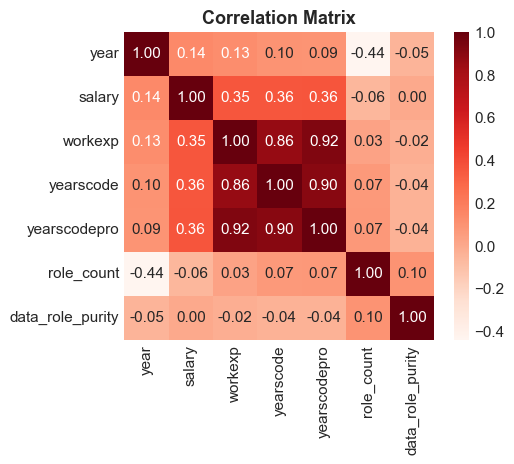

In [16]:
# Correlation Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap=plt.cm.Reds) 
plt.title('Correlation Matrix')
plt.show()

📆 Prozentuale Verteilung der Datensätze nach Jahr

In [17]:
display(df.groupby(['year']).size() / len(df) / 100)

year
2020    0.001589
2021    0.002196
2022    0.001751
2023    0.002280
2024    0.001088
2025    0.001097
dtype: float64

🔄 Normalisierung und Aggregatbildung der Features

In [18]:
df_grp = df.copy()

# Normalisierung und Aggregatbildung von kategorialer Variablen
for c in ['remote', 'branch', 'industry', 'icorpm', 'aiselect']:
    # Replace
    df_grp[c] = df_grp[c].replace(getattr(cfg, f"{c}_mapping"))
    explore_unique_values(df_grp, c) # Häufigkeitskontrolle der Kategorien

# Erstellung des ordinalen Rangs
df_grp['education'] = df_grp['education'].replace(cfg.education_mapping).astype(object)
explore_unique_values(df_grp, 'education') # Häufigkeitskontrolle der Kategorien

df_grp['education_rank'] = df_grp['education'].replace(cfg.education_rank_mapping).astype(object)
explore_unique_values(df_grp, 'education_rank') # Häufigkeitskontrolle der Kategorien

# Erstellung des ordinalen Rangs
df_grp['orgsize'] = df_grp['orgsize'].replace(cfg.orgsize_mapping).astype(object)
explore_unique_values(df_grp, 'orgsize') # Häufigkeitskontrolle der Kategorien

df_grp['orgsize_rank'] = df_grp['orgsize'].replace(cfg.orgsize_rank_mapping).astype(object)
explore_unique_values(df_grp, 'orgsize_rank') # Häufigkeitskontrolle der Kategorien

# Bereinigung und Standardisierung des Beschäftigungsstatus
df_grp['employment'] = df_grp['employment'].apply(clean_employment_status)
explore_unique_values(df_grp, 'employment') # Häufigkeitskontrolle der Kategorien

# Zusammenfassung von seltenen Ländern zur Reduzierung der Feature-Breite
#df_grp['country'] = group_rare_categories(df_grp, 'country')
explore_unique_values(df_grp, 'country') # Häufigkeitskontrolle der Kategorien

# Standardisierung der Gehaltswährungen
df_grp['currency'] = df_grp['currency'].apply(categorize_currency)
# Zusammenfassung von seltenen Währungszeichen zur Reduzierung der Feature-Breite
#df_grp['currency'] = group_rare_categories(df_grp, 'currency')
explore_unique_values(df_grp, 'currency') # Häufigkeitskontrolle der Kategorien

for c in ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'opsys', 'activities', 'office_stack']:
    # Dynamisches Laden des passenden Mappings aus der cfg-Klasse (z.B. cfg.language_mapping)
    current_mapping = getattr(cfg, f"{c}_mapping")
    
    # Kaskadierende Ausführung der Transformations-Pipeline
    df_grp = normalize_multivalue_column(df_grp, c, mapping=current_mapping)
    #df_grp = replace_rare_with_other(df_grp, c)
    explore_multivalue_column(df_grp, c)


# Gewichtung der Daten basierend auf dem Aufnahmejahr
# Zuweisung höherer Gewichte an aktuellere Daten zur stärkeren Berücksichtigung zeitlicher Trends
df_grp['temporal_weight'] = df_grp['year'].map({2020: 0.5, 2021: 0.7, 2022: 1.0, 2023: 1.5, 2024: 2.5, 2025: 3.0})

# Imputation fehlender Werte in der Spalte für die Berufserfahrung
df_grp = impute_work_exp(df_grp)

🔍 Spaltenanalyse: 'remote'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 4
Anzeige der ersten 4 Zeilen:
         Häufigkeit  Anteil (%)
remote                         
Unknown       77709       39.12
Hybrid        53561       26.97
Remote        51183       25.77
On-site       16175        8.14
------------------------------------------------------------

🔍 Spaltenanalyse: 'branch'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 3
Anzeige der ersten 3 Zeilen:
                        Häufigkeit  Anteil (%)
branch                                        
Professional                180927       91.09
Coding at Work/Studies       16513        8.31
Other                         1188        0.60
------------------------------------------------------------

🔍 Spaltenanalyse: 'industry'
Zeilen: 198,628     Ausgefüllt (Nicht-NaN): 198,628     Eindeutige Werte: 12
Anzeige der ersten 5 Zeilen:
                                         Häufigkei

📈 EDA: Numerische Merkmale

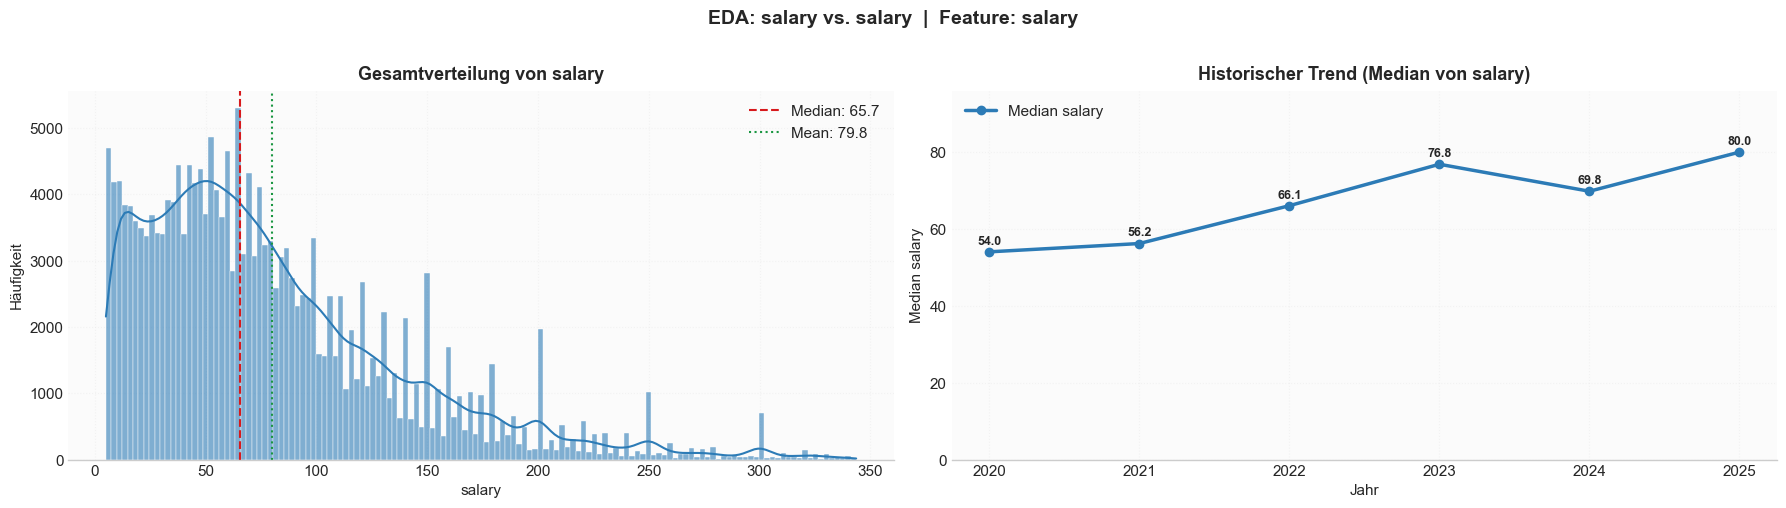

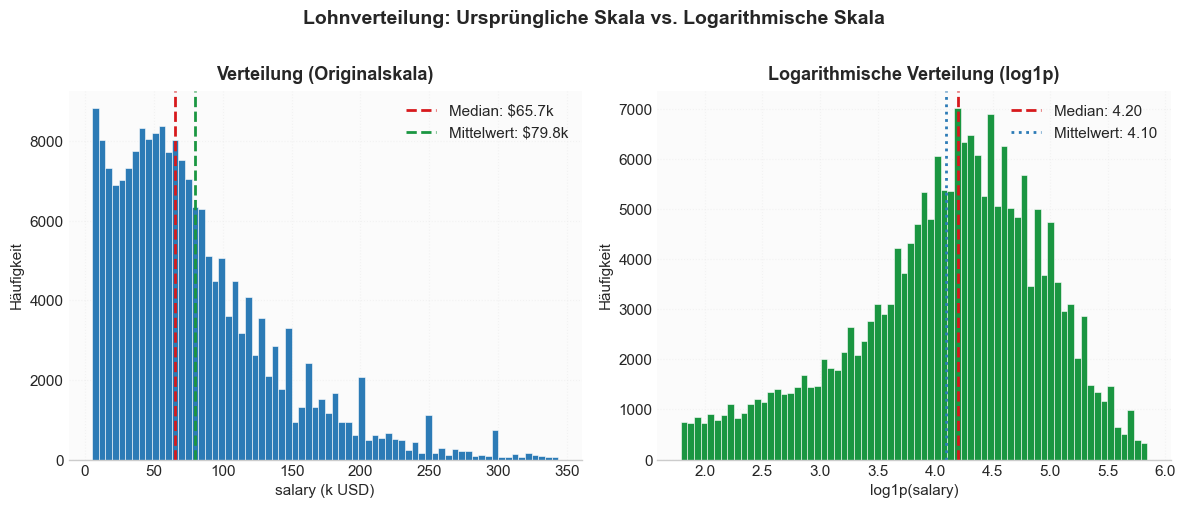

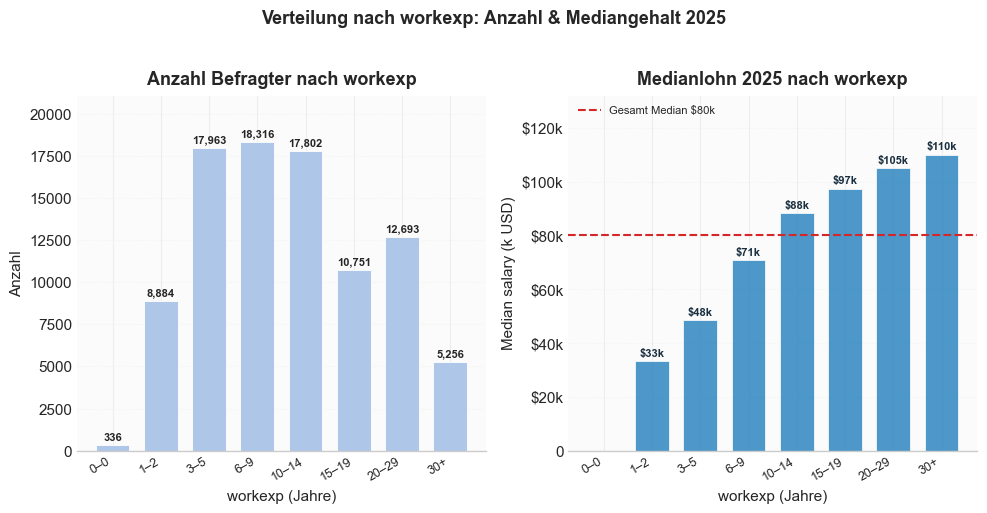

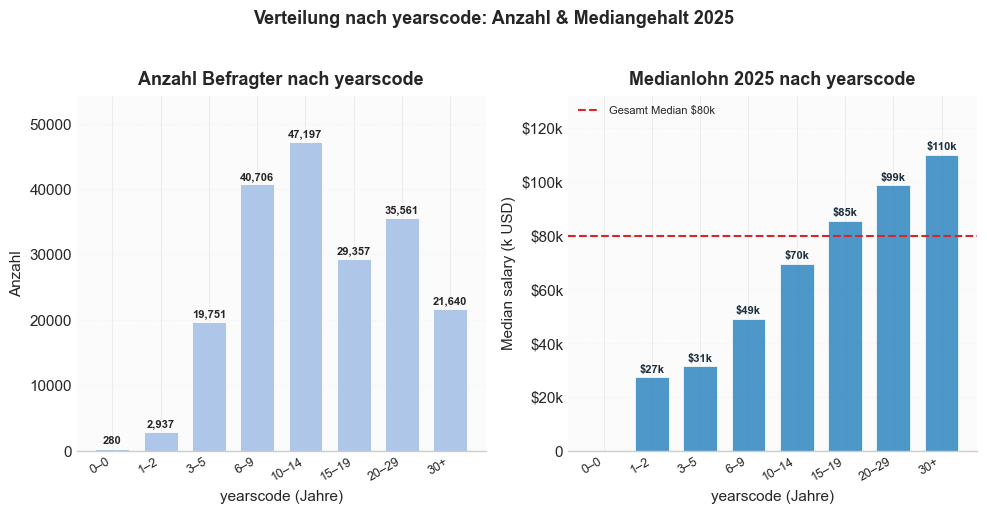

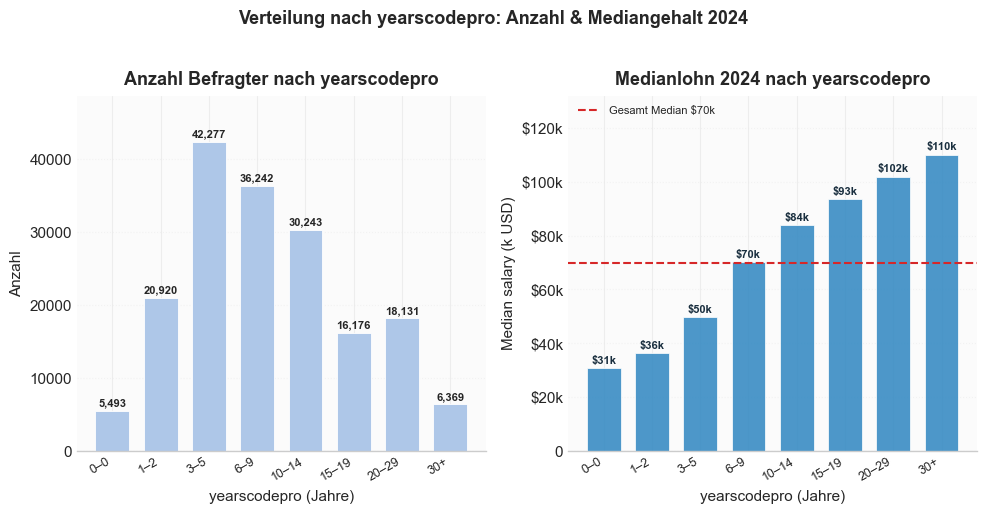

In [19]:
eda_numeric(df, 'salary', plots=(1,4))
eda_numeric(df, 'salary', plots=5)
for c in ['workexp', 'yearscode', 'yearscodepro']:
    eda_numeric_bins(df, c, bins=[0, 1, 3, 6, 10, 15, 20, 30, 50])

📊 EDA: Kategoriale Merkmale

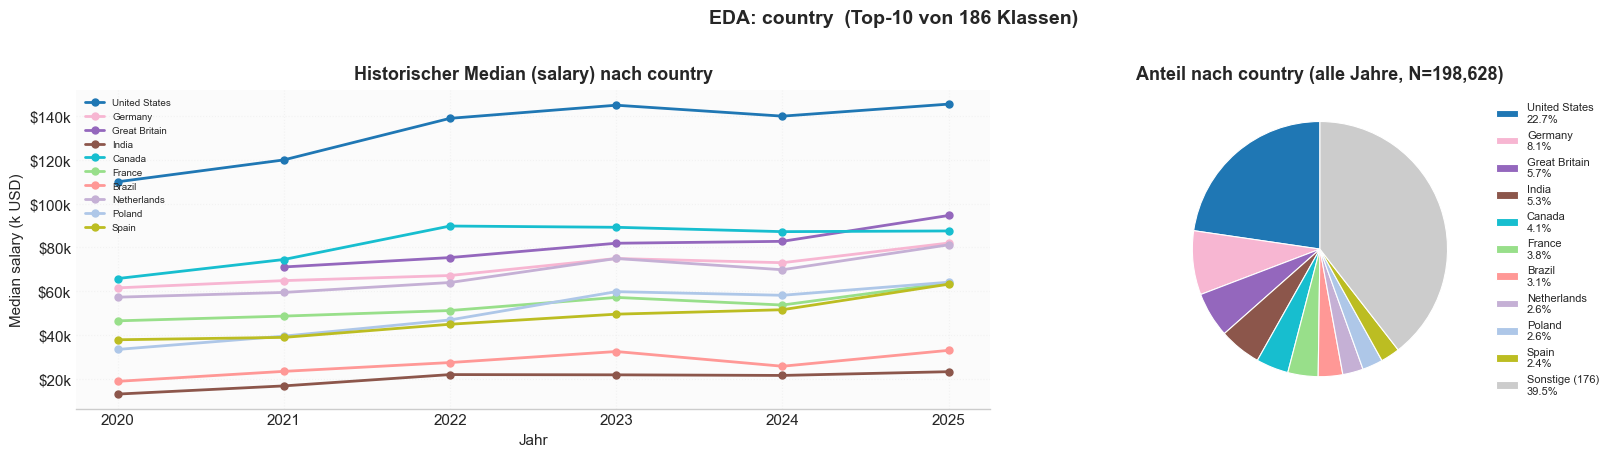

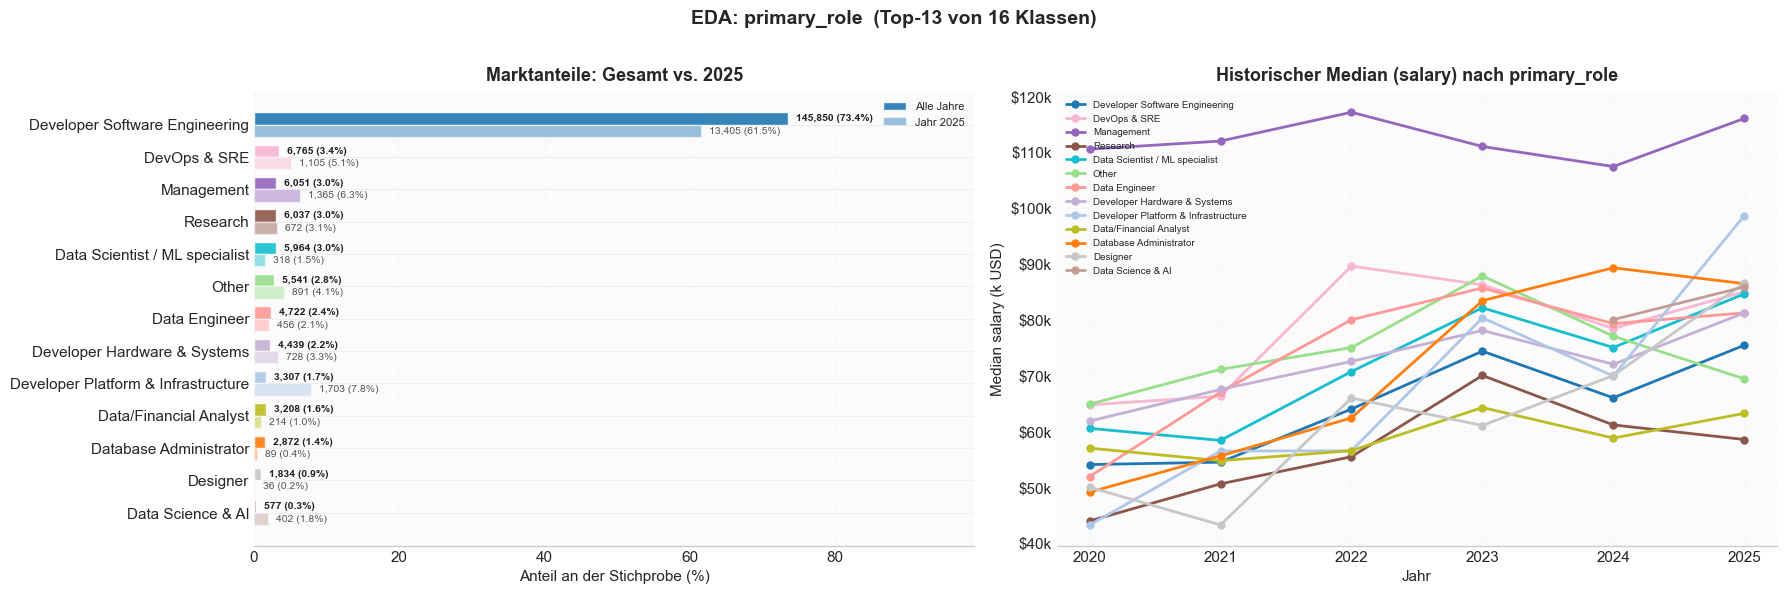

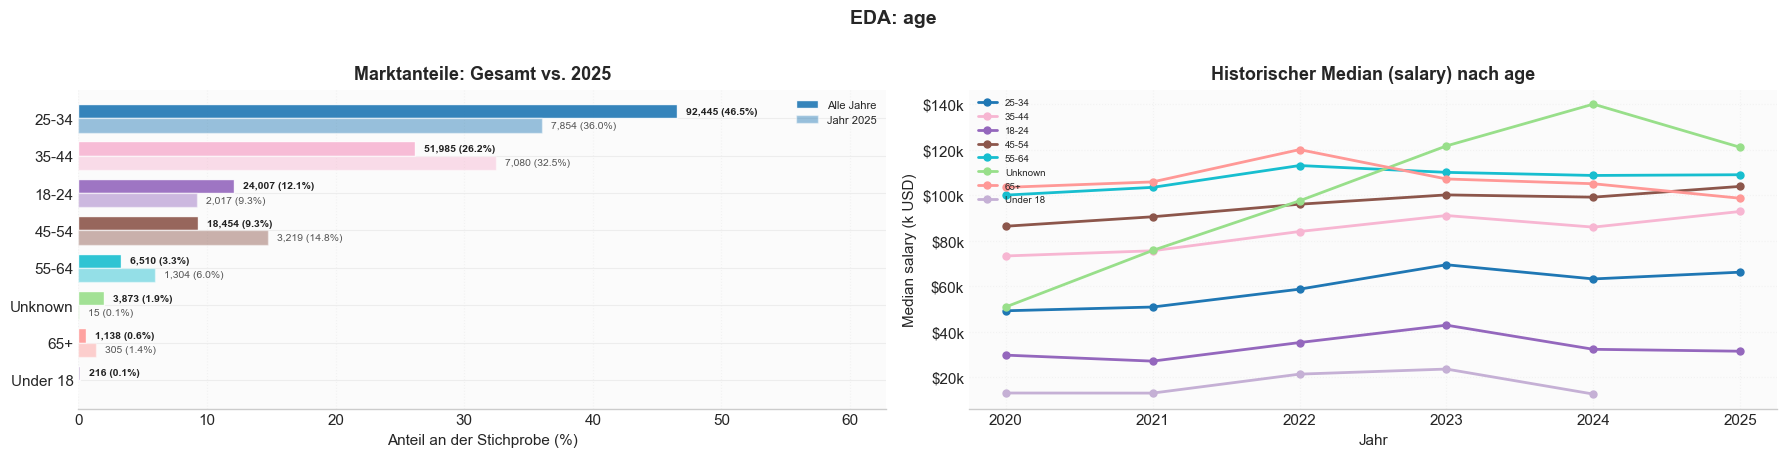

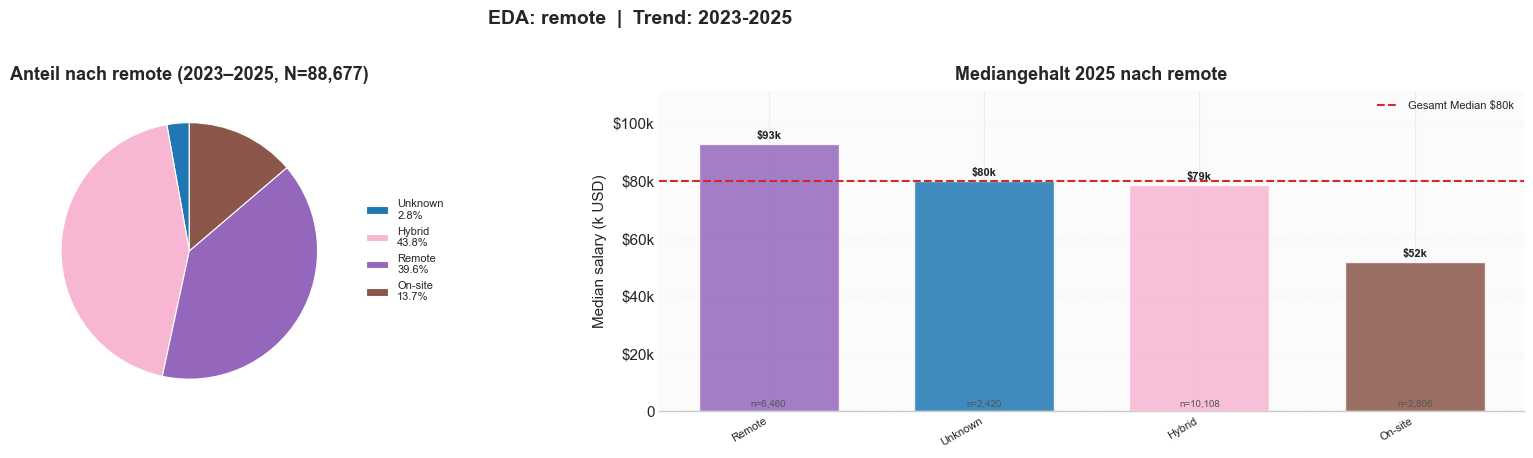

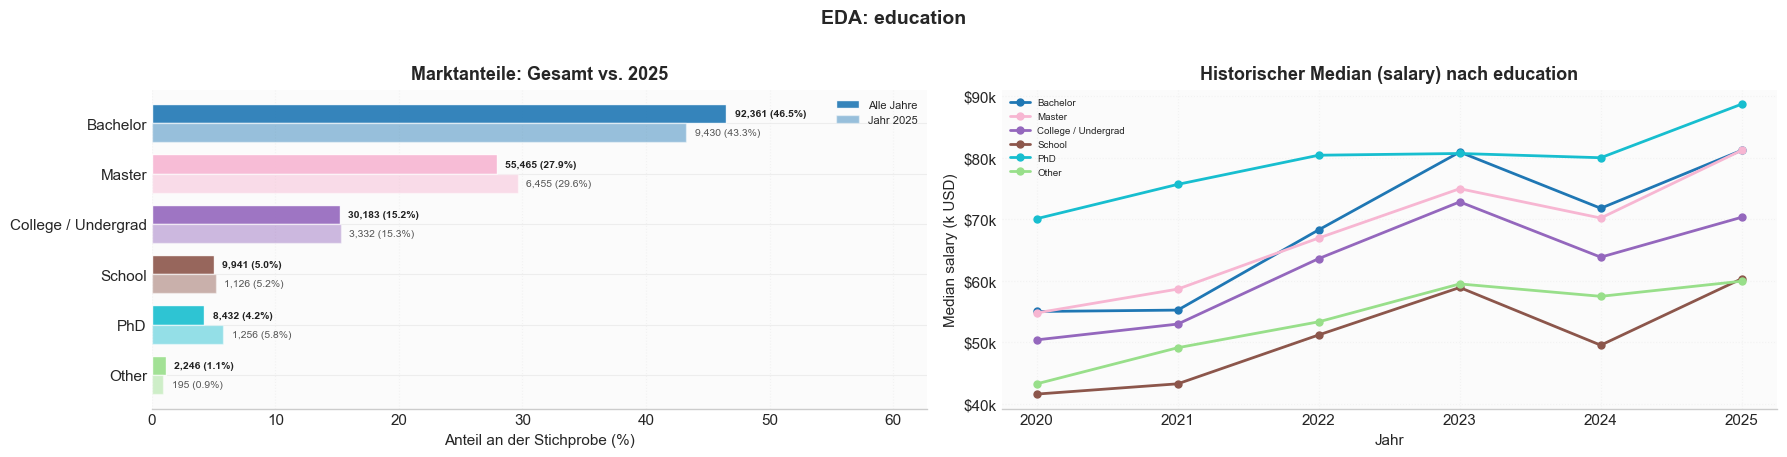

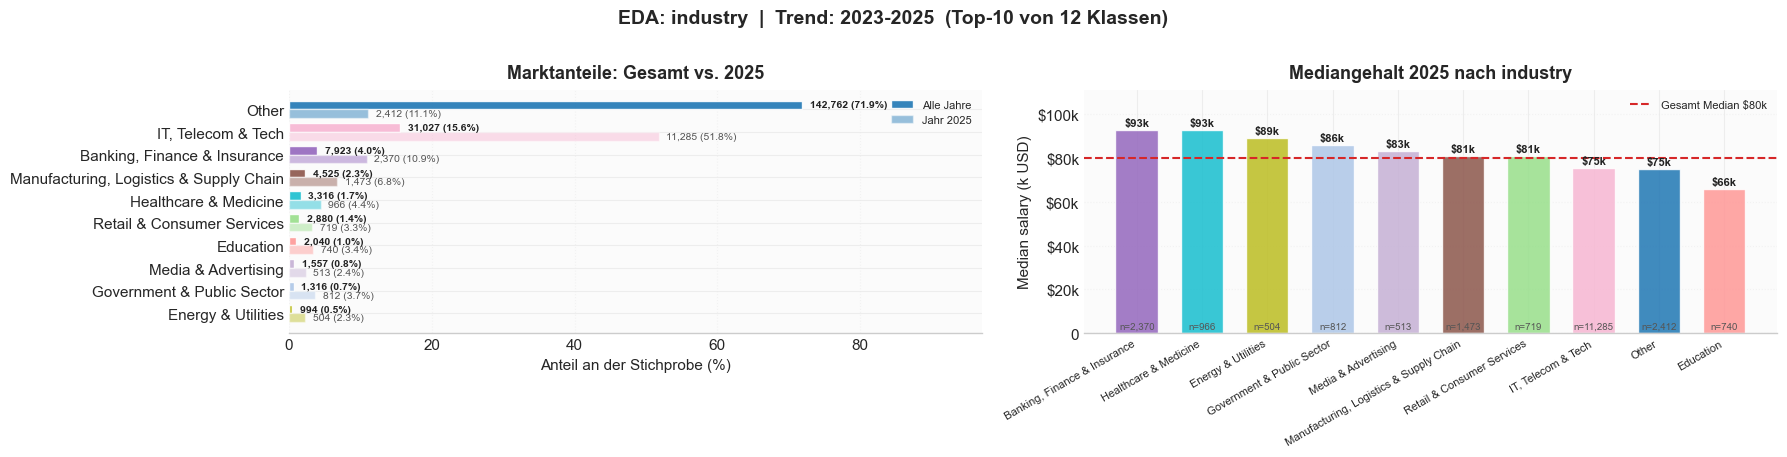

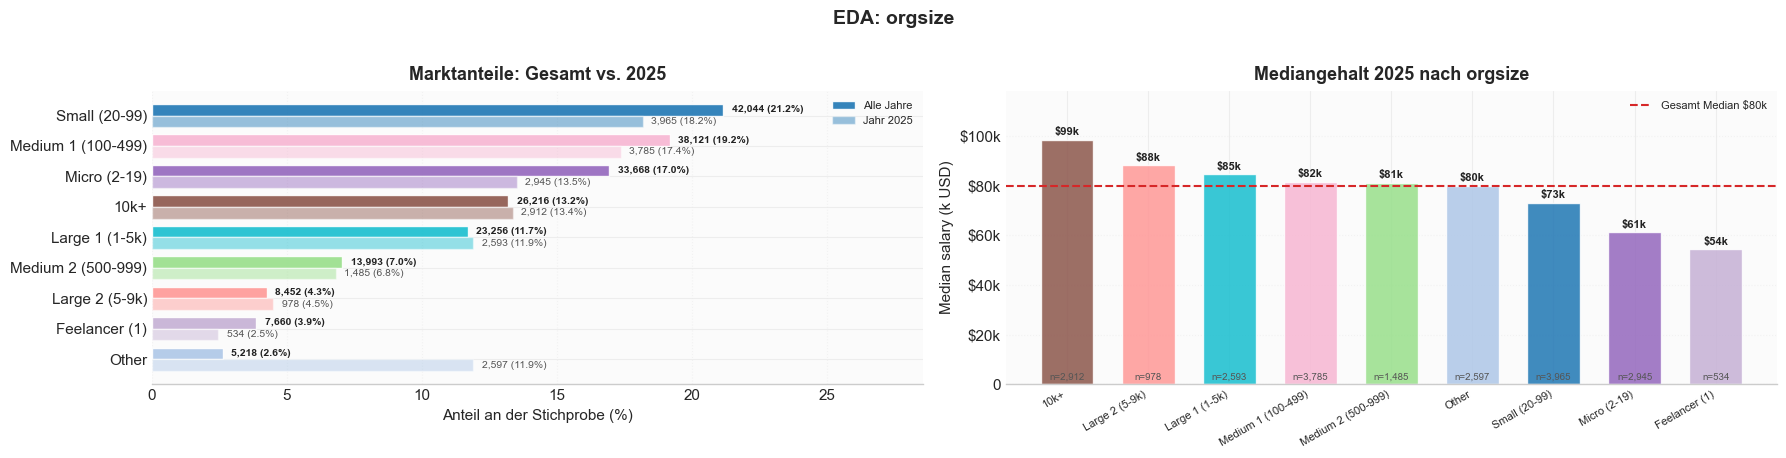

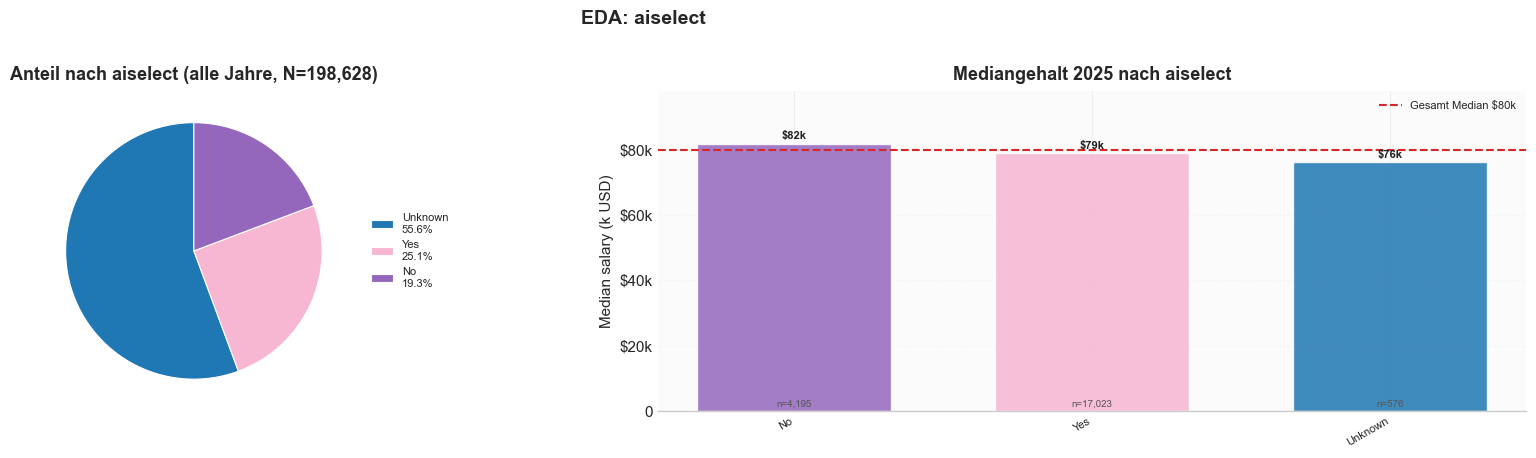

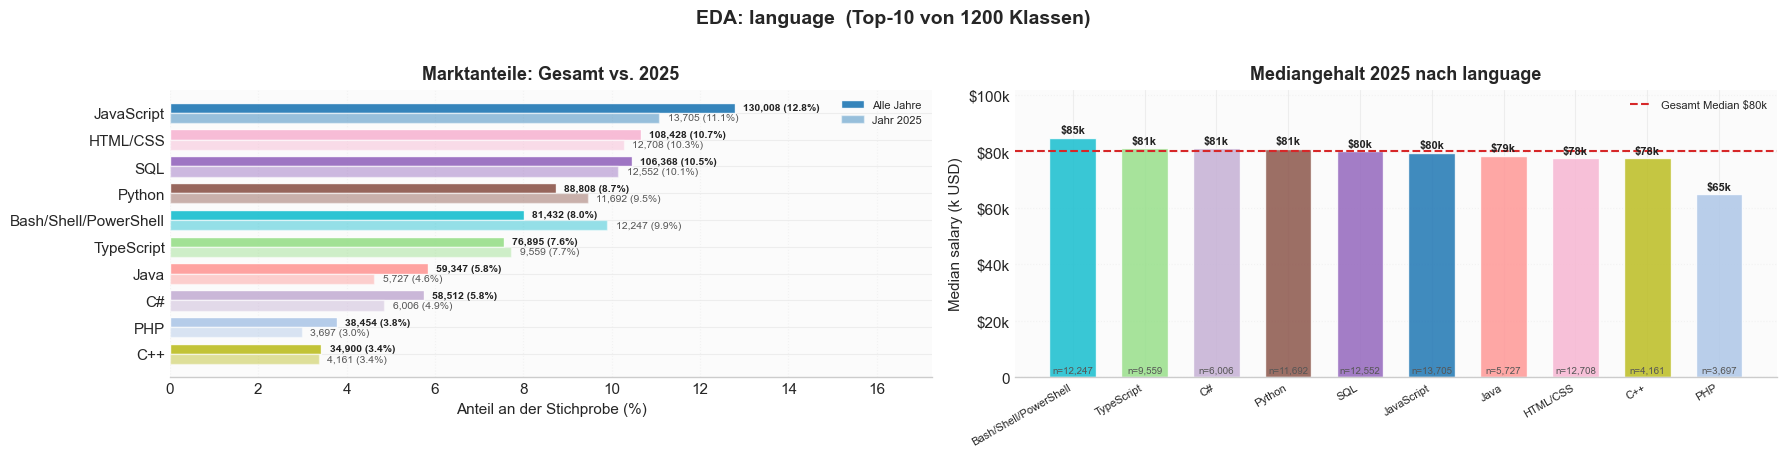

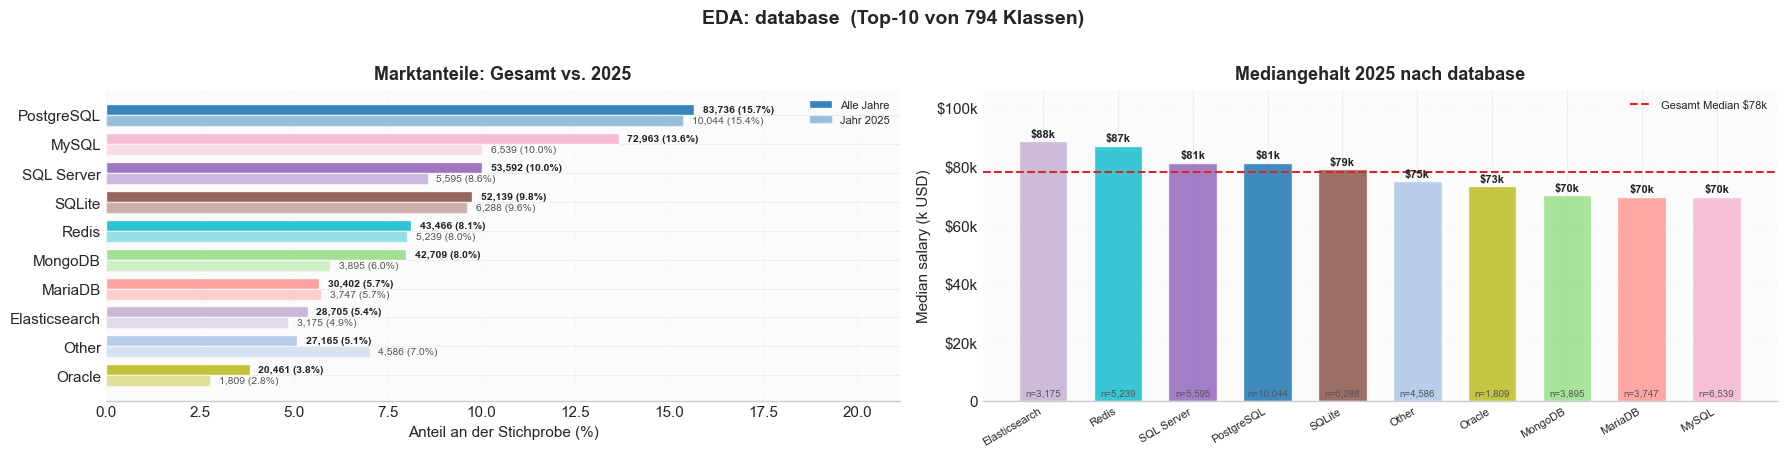

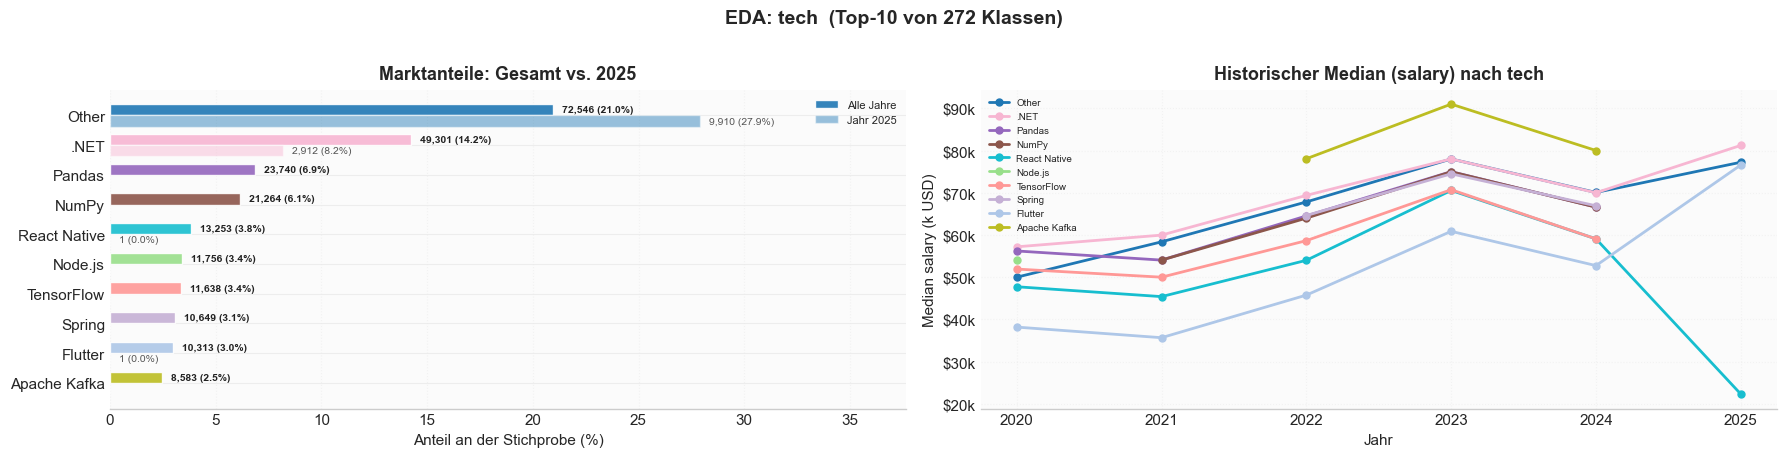

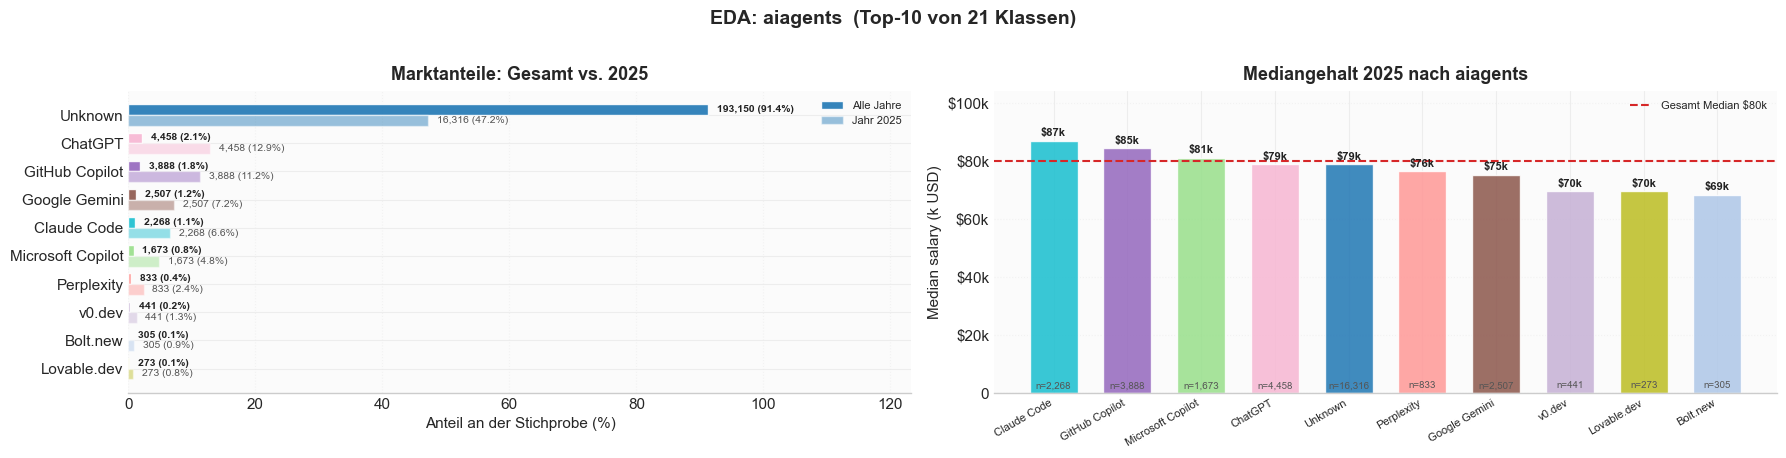

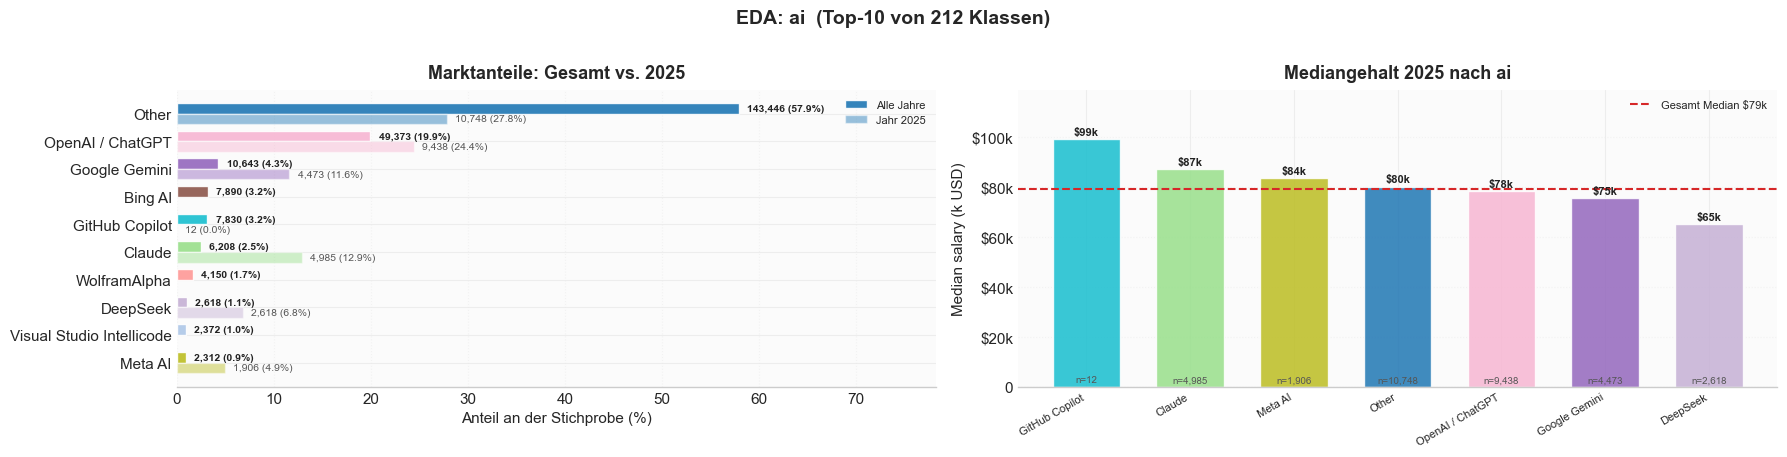

In [20]:
eda_categorical(df, 'country', plots=[8, 4], top_n=10)
eda_categorical(df, 'primary_role', plots=[1, 4], top_n=13)
eda_categorical(df, 'age', plots=[1, 4])
eda_categorical(df_grp, 'remote', plots=[8, 9], trend_years=(2023, 2025))
eda_categorical(df_grp, 'education', plots=[1, 4])
eda_categorical(df_grp, 'industry', plots=[1, 9], trend_years=(2023, 2025))
eda_categorical(df_grp, 'orgsize', plots=[1, 9])
eda_categorical(df_grp, 'aiselect', plots=[8, 9])

for c in ['language', 'database', 'tech', 'aiagents', 'ai']:
    exploded_df = df_grp.copy()
    exploded_df[c] = exploded_df[c].astype(str).str.split(';') 
    exploded_df = exploded_df.explode(c)
    exploded_df = exploded_df.reset_index(drop=True)
    if c in ['tech']:
        eda_categorical(exploded_df, c, plots=[1, 4])
    else:
        eda_categorical(exploded_df, c, plots=[1, 9])


EDA für Datenrollen

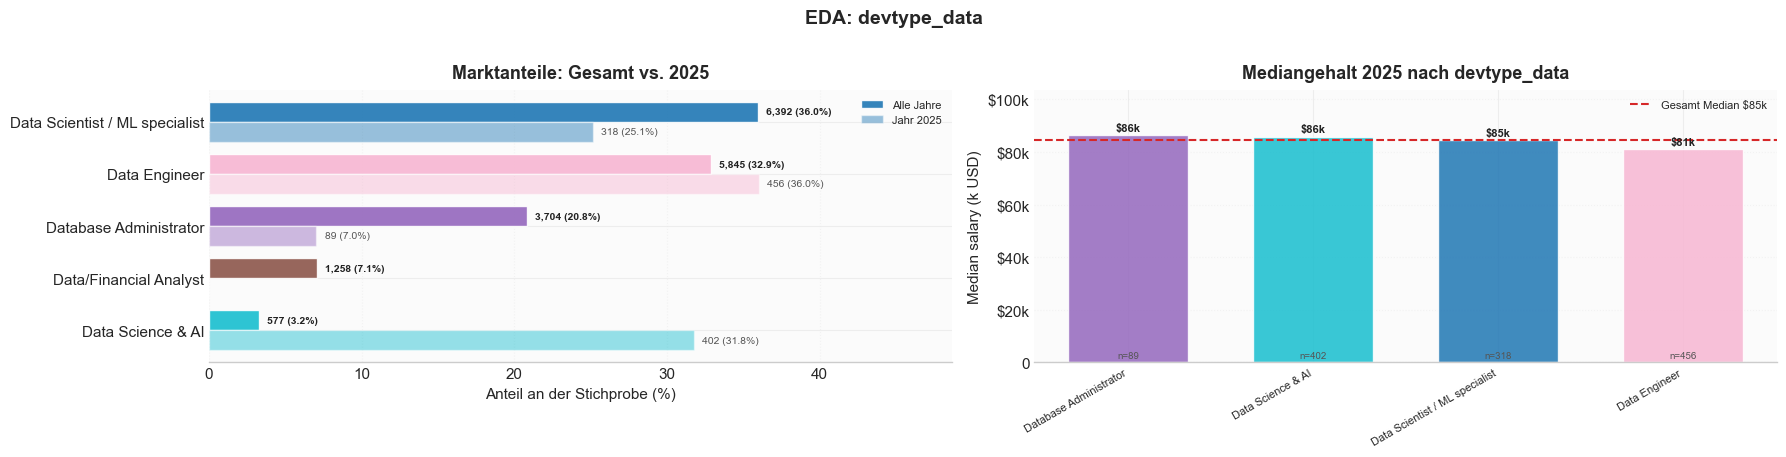

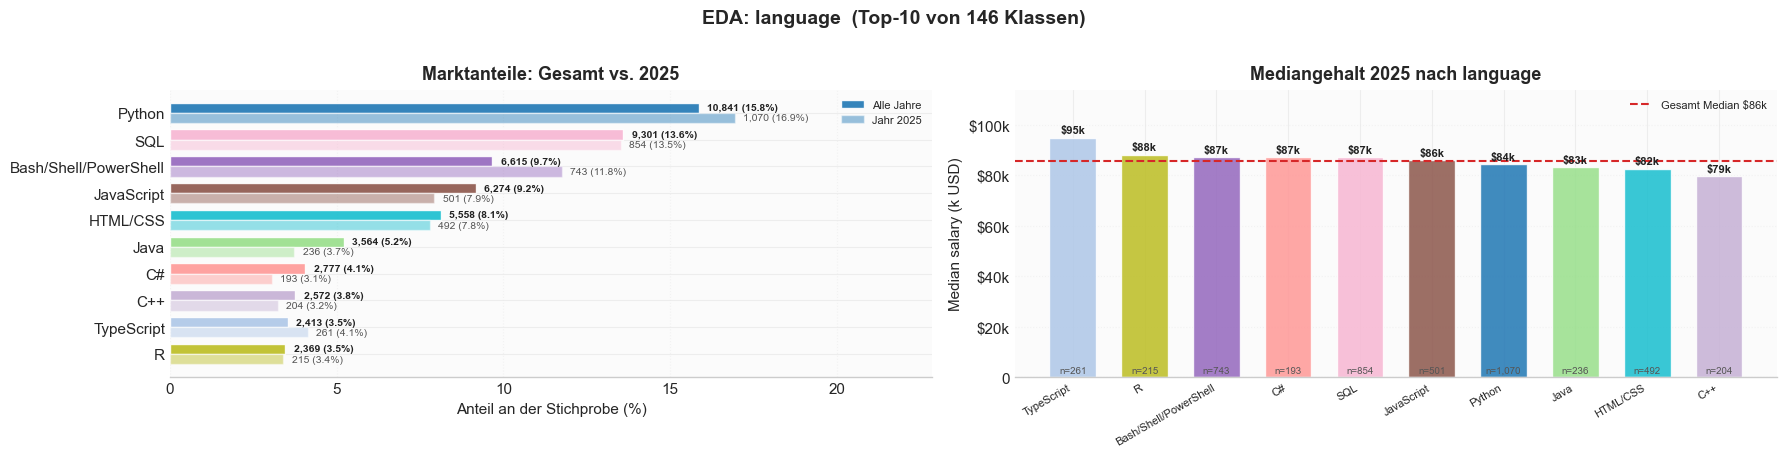

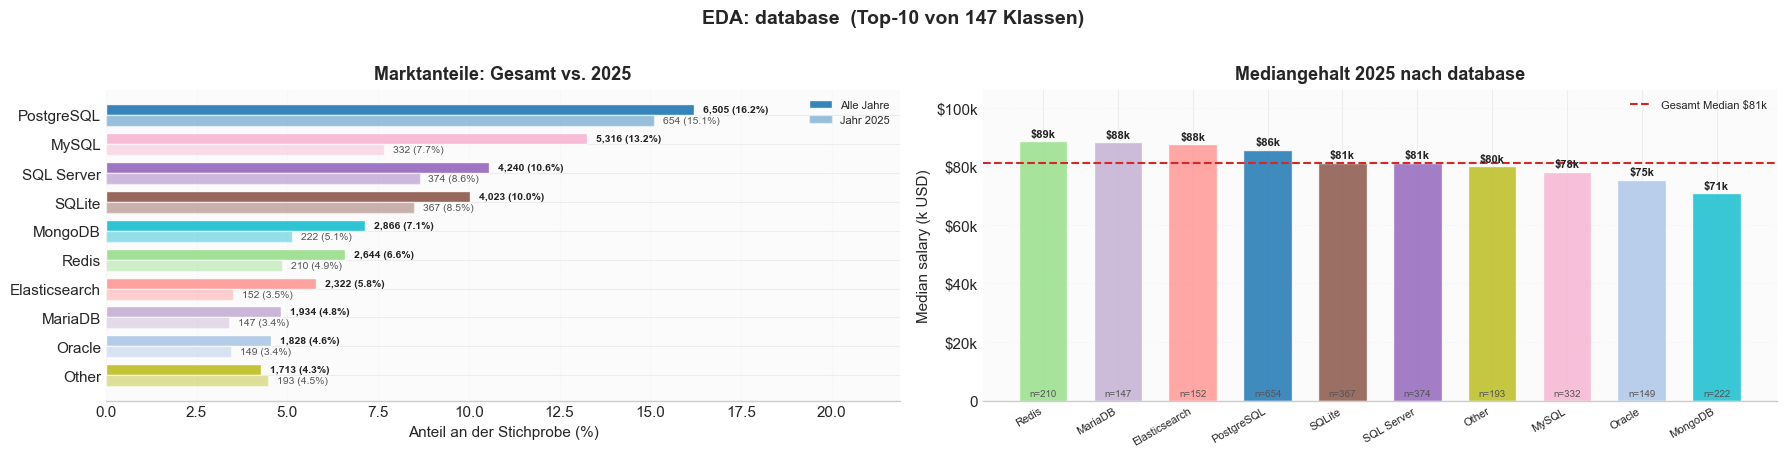

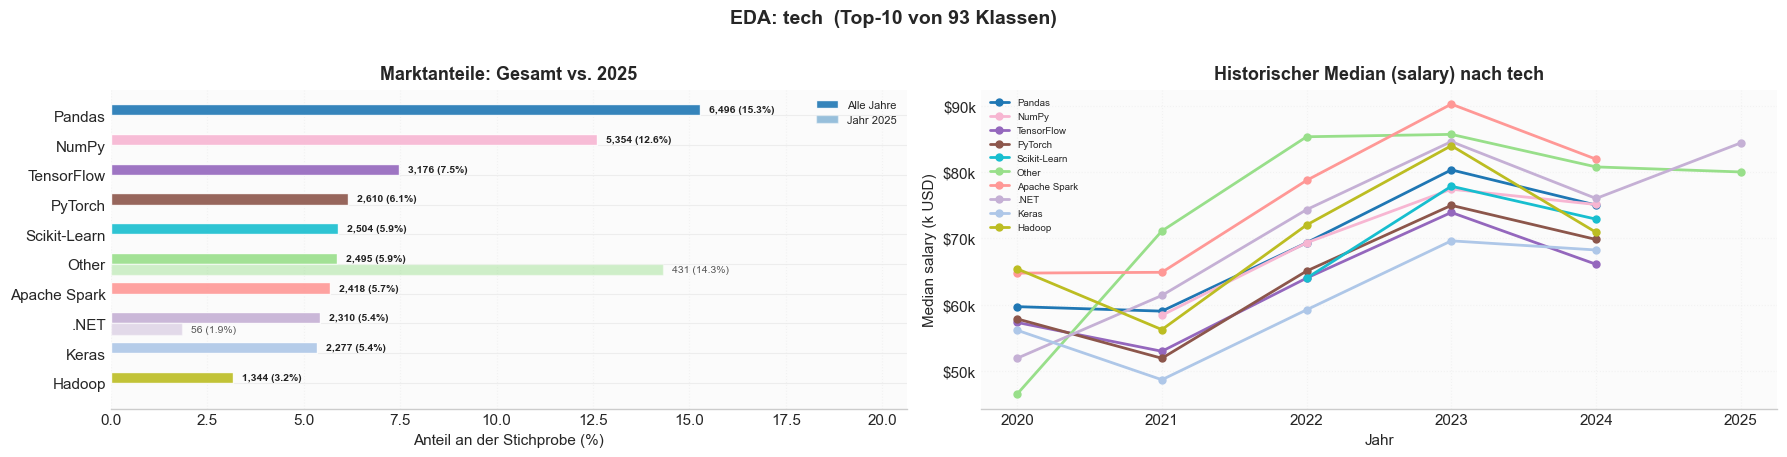

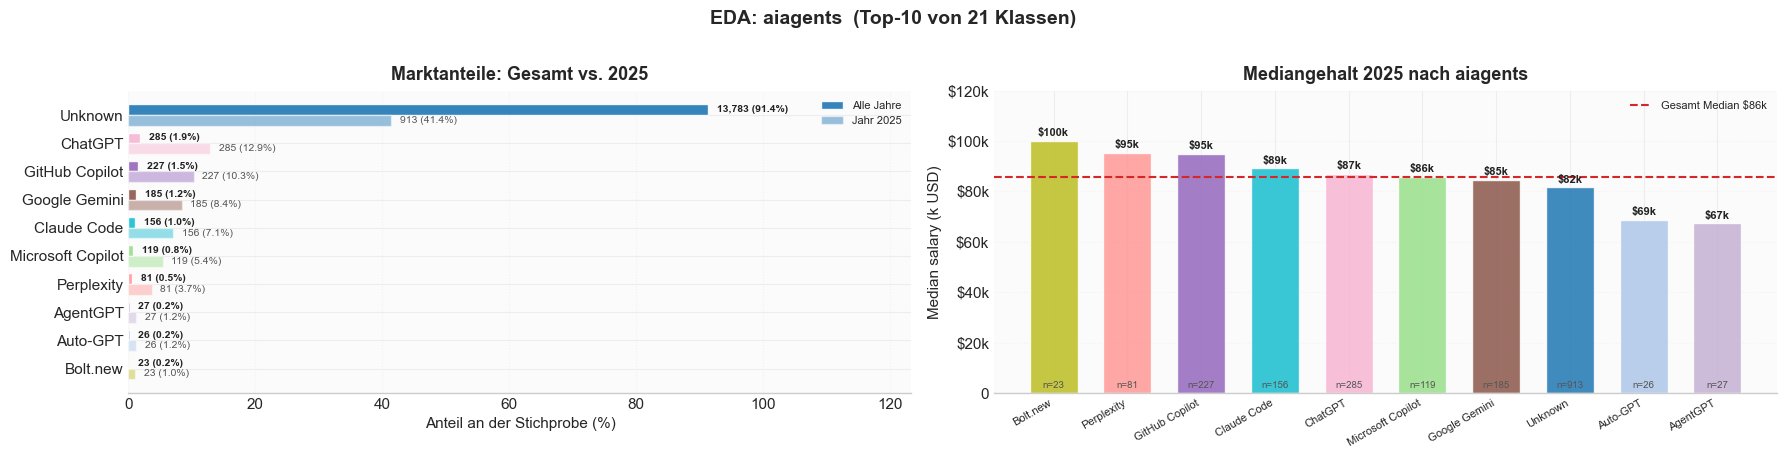

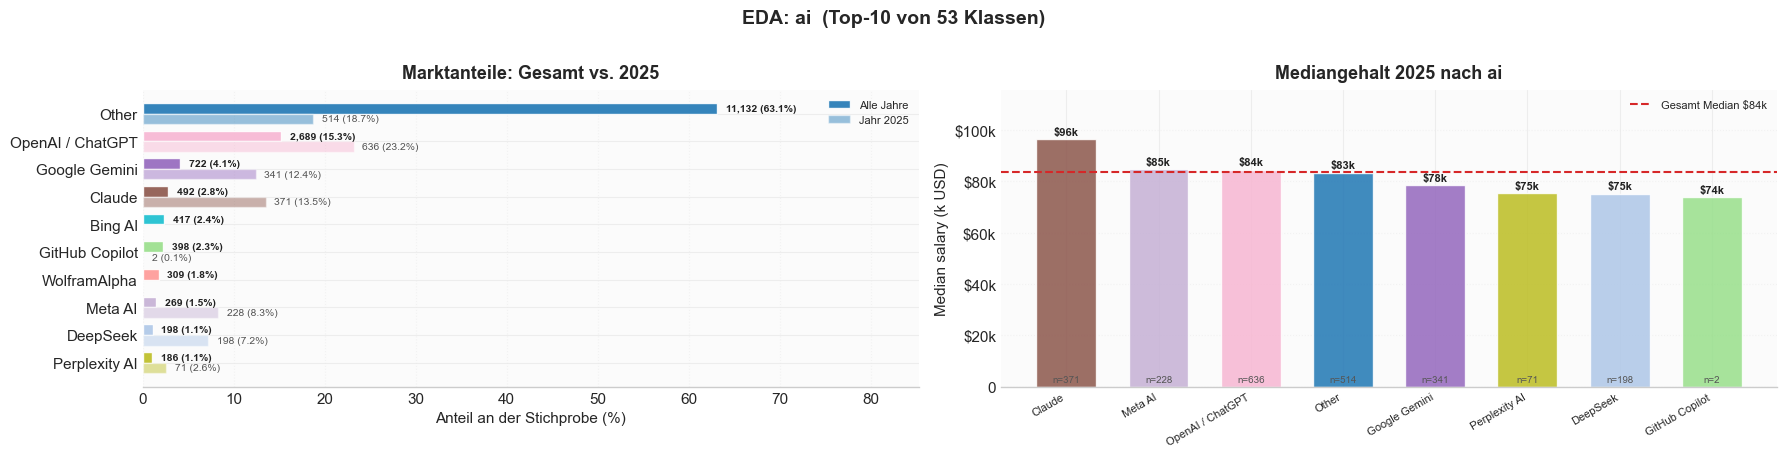

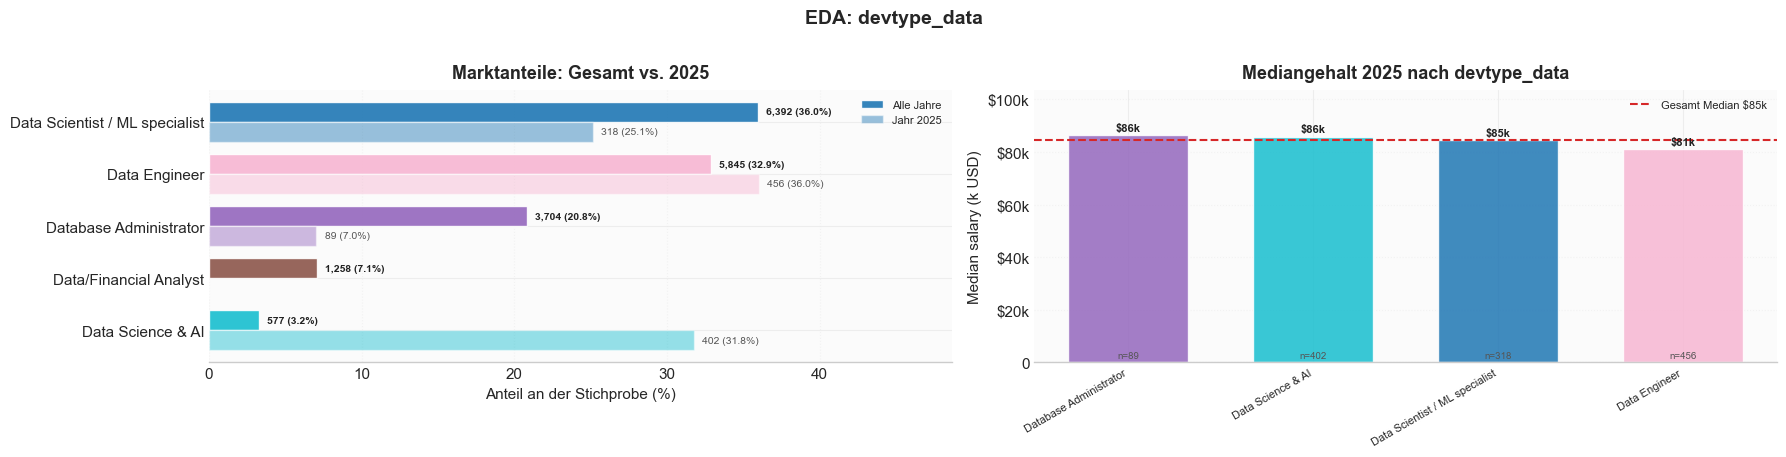

In [21]:
for c in ['devtype_data', 'language', 'database', 'tech', 'aiagents', 'ai', 'devtype_data']:
    exploded_df = df_grp.copy()
    exploded_df[c] = exploded_df[c].astype(str).str.split(';') 
    exploded_df = exploded_df.explode(c)
    exploded_df = exploded_df.reset_index(drop=True)
    if c in ['tech']:
        eda_categorical(exploded_df[exploded_df["primary_role"].isin(set(cfg.data_role_mapping.values()))], c, plots=[1, 4])
    else:
        eda_categorical(exploded_df[exploded_df["primary_role"].isin(set(cfg.data_role_mapping.values()))], c, plots=[1, 9])

---
## ⚙️ 3. Base Model

In [22]:
# Aufteilung des Datensatzes in Trainings- und Testdaten für die Modellierung
features_train, features_test, target_train, target_test = data_split(df)

# Definition der Spaltenkategorien: Numerische und kategoriale Merkmale
num_cols_raw  = ['year', 'workexp', 'yearscode', 'yearscodepro']
cat_cols_raw  = ['country', 'remote', 'branch', 'education', 'employment', 'industry', 'orgsize', 'icorpm', 'aiselect', 'age']

# Konfiguration der Transformation-Pipelines
# Kategoriale Variablen: Imputation fehlender Werte und One-Hot-Encoding
cat_transformer_raw = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                ('ohe', OneHotEncoder(sparse_output=False, handle_unknown = 'ignore'))])

# Numerische Variablen: Imputation mit Median und Standardisierung
num_transformer_raw = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]) 

# Zusammenführung der Transformationen mittels ColumnTransformer
preprocessor_raw = ColumnTransformer(transformers = [('cat', cat_transformer_raw, cat_cols_raw),
                                                     ('num', num_transformer_raw, num_cols_raw)], remainder = 'drop') 

# Pipeline für das lineare Regressionsmodell
model_base = Pipeline(steps = [('preprocessor', preprocessor_raw),
                               ('LinearRegression (base)', LinearRegression())])

# Training des Basismodells mit logarithmierter Zielvariable (log1p)
model_base.fit(features_train, np.log1p(np.ravel(target_train)))

# Generierung und Rücktransformation der Vorhersagen (expm1)
target_pred_base = np.expm1(model_base.predict(features_test))

# Initialisierung und Aktualisierung des Ergebnis-DataFrames zur Modellbewertung
df_results = pd.DataFrame(columns=["MAE", "RMSE", "R2"])
df_results.index.name = "Model"
df_results = result(df_results, "LinearRegression (base)", target_test, target_pred_base)

# Ausgabe der Metriken des Basismodells
df_results

,MAE,RMSE,R2
Model,,,
LinearRegression (base),36.798989,53.661453,0.253412


---
## ➗ 4. Train-Test-Split

In [23]:
# Aufteilung des Datensatzes in Trainings- und Testdaten für die Modellierung
features_train, features_test, target_train, target_test = data_split(df)

🌍 Target Encoding für Länder und Regionen

In [24]:
# ── Вычисляем медианы ТОЛЬКО на train ────────────────────────────────────
train_df      = df.loc[features_train.index].copy()
global_median = train_df["salary"].median()

country_median      = train_df.groupby("country")["salary"].median()
country_role_median = train_df.groupby(["country", "primary_role"])["salary"].median()
role_median         = train_df.groupby("primary_role")["salary"].median()
role_p75            = train_df.groupby("primary_role")["salary"].quantile(0.75)
region_median       = train_df.groupby("country_region")["salary"].median()
region_role_median  = train_df.groupby(["country_region", "primary_role"])["salary"].median()

# ── Применяем ко всему df (train + test) через маппинг из train ───────────
df["country_salary_median"] = df["country"].map(country_median).fillna(global_median)
df["country_role_median"]   = df.apply(
    lambda row: country_role_median.get(
        (row["country"], row["primary_role"]), global_median), axis=1,
)
df["role_salary_median"]    = df["primary_role"].map(role_median).fillna(global_median)
df["role_salary_p75"]       = df["primary_role"].map(role_p75).fillna(global_median)
df["region_salary_median"]  = df["country_region"].map(region_median).fillna(global_median)
df["region_role_median"]    = df.apply(
    lambda row: region_role_median.get(
        (row["country_region"], row["primary_role"]), global_median
    ), axis=1,
)

# Взвешивать редкие страна+роль комбинации выше
combo_counts = df.groupby(["country", "primary_role"])["salary"].transform("count")
df["sample_weight"] = 1 / np.log1p(combo_counts)

# ── Контроль ──────────────────────────────────────────────────────────────
print(f"Globaler Median:          ${global_median:.1f}k")
print(f"Länder mit Median:        {country_median.shape[0]}")
print(f"Land+Rolle Kombinationen: {country_role_median.shape[0]}")
print(f"Rollen mit Median:        {role_median.shape[0]}")
print(f"Regionen mit Median:      {region_median.shape[0]}")
print(f"Region+Rolle Kombin.:     {region_role_median.shape[0]}")

for col in ["country_salary_median", "country_role_median",
            "role_salary_median",    "role_salary_p75",
            "region_salary_median",  "region_role_median"]:
    print(f"  {col:<28} min={df[col].min():.1f}  "
          f"median={df[col].median():.1f}  max={df[col].max():.1f}")

# ── Обновляем features_train и features_test ──────────────────────────────
features_train = df.loc[features_train.index].drop(columns=["salary"])
features_test  = df.loc[features_test.index].drop(columns=["salary"])

Globaler Median:          $64.6k
Länder mit Median:        184
Land+Rolle Kombinationen: 1624
Rollen mit Median:        16
Regionen mit Median:      15
Region+Rolle Kombin.:     239
  country_salary_median        min=6.5  median=64.9  max=240.0
  country_role_median          min=5.1  median=64.6  max=289.1
  role_salary_median           min=21.7  median=62.9  max=110.0
  role_salary_p75              min=41.2  median=101.9  max=165.3
  region_salary_median         min=15.5  median=64.9  max=120.0
  region_role_median           min=7.3  median=64.9  max=175.0


🔧 Features Engineering

In [ ]:
def features_engineering(df_features):
    df_features = normalize_multivalue_column(df_features, 'devtype_data', mapping=cfg.data_role_mapping)
    for c in ['remote', 'branch', 'industry', 'icorpm', 'aiselect']:
        df_features[c] = df_features[c].replace(getattr(cfg, f"{c}_mapping"))
    df_features['education'] = df_features['education'].replace(cfg.education_mapping).astype(object)
    df_features['education_rank'] = df_features['education'].replace(cfg.education_rank_mapping).astype(object)
    df_features['orgsize'] = df_features['orgsize'].replace(cfg.orgsize_mapping).astype(object)
    df_features['orgsize_rank'] = df_features['orgsize'].replace(cfg.orgsize_rank_mapping).astype(object)
    df_features['employment'] = df_features['employment'].apply(clean_employment_status)
    
    df_features["country_region"] = (df_features["country"].map(cfg.region_mapping).fillna("Other"))    
    # df_features["is_usa"] = (df_features["country"].isin(["United States", "United States of America"])).astype(int)
    # df_features["is_germany"] = (df_features["country"] == "Germany").astype(int)
    # df_features["is_uk"] = (df_features["country"].isin(["United Kingdom", "United Kingdom of Great Britain and Northern Ireland"])).astype(int)
    # df_features["is_india"] = (df_features["country"] == "India").astype(int)
    df_features['country'] = df_features['country'].replace({'United States of America': 'United States',
                                                'United Kingdom of Great Britain and Northern Ireland': 'Great Britain'})
    df_features['country'] = group_rare_categories(df_features, 'country')
    df_features['currency'] = df_features['currency'].apply(categorize_currency)
    df_features['currency'] = group_rare_categories(df_features, 'currency')
    for c in ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'opsys', 'activities', 'office_stack']:
        current_mapping = getattr(cfg, f"{c}_mapping")
        df_features = normalize_multivalue_column(df_features, c, mapping=current_mapping)
        df_features = replace_rare_with_other(df_features, c)
    df_features["temporal_weight"] = df_features["year"].map({2020: 0.5, 2021: 0.7, 2022: 1.0, 2023: 1.5, 2024: 2.5, 2025: 3.0})
    df_features = impute_work_exp(df_features)

    df_features['hobbyyears'] = df_features['yearscode'] - df_features['yearscodepro']
    df_features['devtype_data'] = (df_features['devtype_data'].str.split(";").str[0].str.strip().replace('None', 'None'))
    df_features['devtype_other'] = (df_features['devtype_other'].str.split(";").str[0].str.strip().replace('None', 'None'))
    return df_features

In [26]:
features_train = features_engineering(features_train)
features_test = features_engineering(features_test)

In [27]:
overview(features_train)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,176834,0,0.000000,5,"[2020, 2021, 2022, 2023, 2024]"
currency,str,176834,0,0.000000,5,"[USD, GBP, EUR, Other, INR]"
country,str,176834,0,0.000000,5,"[United States, Other, Germany, India, Great B..."
age,str,176834,0,0.000000,8,"[35-44, 18-24, 45-54, 25-34, Unknown, 55-64, 6..."
workexp,float64,176834,0,0.000000,71,"[12.0, 5.0, 6.0, 26.0, 3.0, 28.0, 4.0, 23.0, 2..."
yearscode,float64,176228,606,0.342694,52,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
yearscodepro,float64,175958,876,0.495380,52,"[13.0, 4.0, 2.0, 7.0, 20.0, 1.0, 23.0, 3.0, 10..."
remote,str,176834,0,0.000000,4,"[Unknown, Hybrid, Remote, On-site]"
branch,str,176834,0,0.000000,2,"[Professional, Coding at Work/Studies]"
devtype,str,176834,0,0.000000,4625,"[Developer Software Engineering, Database Admi..."


---
## 🧠 5. Machine Learning

🛠️ Preprocessing

In [28]:
# Spaltengruppen für den Preprocessing-Prozess
cat_cols  = ['country', 'currency', 'remote', 'branch', 'employment', 'industry', 'icorpm', 'aiselect', 'education', 'orgsize', 'country_region', 'age', 'primary_role']
multi_cols = ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'activities', 'opsys', 'office_stack', 'devtype'] 
# pca_cols  = []
num_cols   = ['year', 'education_rank', 'orgsize_rank', 'workexp', 'yearscode', 'hobbyyears', 
                "country_salary_median",
                "country_role_median",
                #"role_salary_median",
                #"role_salary_p75",
                "region_salary_median",
                "region_role_median",
                "sample_weight"
              ]  #'temporal_weight',

# Verarbeitung der kategorischen Daten
for c in cat_cols:
    features_train[c] = features_train[c].fillna('Unknown')
    features_train[c] = features_train[c].astype('category')

# Verarbeitung der numerischen Daten
for c in num_cols:
    # Umwandlung in Fließkommazahlen und Imputation fehlender Werte durch den Median
    features_train[c] = features_train[c].fillna(features_train[c].median())
    features_train[c] = features_train[c].astype('float32')
    
    # Durchführung der automatischen Typoptimierung basierend auf Wertebereichen
    if (features_train[c] % 1 != 0).any():
        # Zuweisung des Datentyps 'float32' bei Vorhandensein von Nachkommastellen
        features_train[c] = features_train[c].astype('float32')
    else:
        if features_train[c].min() < 0:
            # Klassifizierung für vorzeichenbehaftete Ganzzahlen
            if features_train[c].min() >= -128 and features_train[c].max() <= 127:
                features_train[c] = features_train[c].astype('int8')
            elif features_train[c].min() >= -32768 and features_train[c].max() <= 32767:
                features_train[c] = features_train[c].astype('int16')
            else:
                features_train[c] = features_train[c].astype('int32')
        else:
            # Klassifizierung für vorzeichenlose Ganzzahlen
            if features_train[c].max() < 255:
                features_train[c] = features_train[c].astype('uint8')
            elif features_train[c].max() < 65535:
                features_train[c] = features_train[c].astype('uint16')
            else:
                features_train[c] = features_train[c].astype('int32')

# weights_all = compute_sample_weights(features_train, strategy='purity')
# weights_train = weights_all.loc[features_train.index]

🔀 Definition der Transformation-Pipelines

In [29]:
# Transformation für numerische Daten: Imputation durch Median und Skalierung
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler())]) 

# Transformation für PCA-Komponenten: Median-Imputation, Skalierung und anschließend PCA
# pca_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
#                                     ('scaler', StandardScaler()), 
#                                     ('pca', PCA(n_components=1))])

# Transformation für kategoriale Daten: Imputation durch häufigsten Wert und One-Hot-Encoding
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])

# Multilabel-Vektorisierung mittels CountVectorizer (Trennung durch Semikolon)
vectorizer_step = CountVectorizer(tokenizer=lambda x: str(x).split(';'), lowercase=False)

# Liste der Transformer für den ColumnTransformer
transformers_list = [('num', num_transformer, num_cols),
                     ('cat', cat_transformer, cat_cols),
                     #('pca', pca_transformer, pca_cols)
                     ]

# Automatische Hinzufügung jeder Multivalue-Spalte einzeln.
# Dies stellt sicher, dass der ColumnTransformer sie als 1D-Vektoren verarbeitet
for col in multi_cols:
    transformers_list.append((f'multi_{col}', vectorizer_step, col))
    
# Initialisierung des finalen Preprocessors
preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')

👀 Transformation

In [30]:
# Anwendung des Preprocessors auf den Trainingsdatensatz
f_transformed = preprocessor.fit_transform(features_train)

# Extraktion der Spaltennamen nach der Anwendung von OHE und CountVectorizer
column_names = preprocessor.get_feature_names_out()

# Rekonstruktion des DataFrames
# Prüfung der Datenstruktur (Sparse-Matrix vs. Array) zur korrekten Konvertierung
if hasattr(f_transformed, "toarray"):
    features_transformed = pd.DataFrame(f_transformed.toarray(), columns=column_names, index=df.index)
else:
    features_transformed = pd.DataFrame(f_transformed, columns=column_names, index=features_train.index)

# Ausgabe der Dimensionen vor und nach der Transformation zur Validierung
print(f"Dimensionen des DataFrames VORHER: {features_train.shape}")
print(f"Dimensionen des DataFrames NACHHER: {features_transformed.shape}")

# Anzeige der ersten Datenzeilen zur Qualitätskontrolle
display(features_transformed.head())

Dimensionen des DataFrames VORHER: (176834, 44)
Dimensionen des DataFrames NACHHER: (176834, 206)


,num__year,num__education_rank,num__orgsize_rank,num__workexp,num__yearscode,num__hobbyyears,num__country_salary_median,num__country_role_median,num__region_salary_median,num__region_role_median,...,multi_devtype__DevOps & SRE,multi_devtype__Developer Community & Specialized,multi_devtype__Developer Hardware & Systems,multi_devtype__Developer Platform & Infrastructure,multi_devtype__Developer Software Engineering,multi_devtype__Management,multi_devtype__Other,multi_devtype__Research,multi_devtype__Security,multi_devtype__Student
7,-1.457177,-0.076299,-0.699298,0.113671,0.208799,-0.294857,1.542810,1.477026,1.447500,1.363040,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,-1.457177,0.983747,-1.094120,-0.712703,-0.727230,-0.294857,-0.138849,-0.345215,0.005952,-0.290442,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10,-1.457177,-0.076299,1.669631,-0.594650,-0.519224,0.667482,-0.138849,-0.149217,0.005952,0.020637,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
11,-1.457177,-1.136345,-1.094120,-0.712703,-0.831234,-1.257197,-0.686848,-0.950298,-0.508708,-0.747448,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
12,-1.457177,-2.196392,-1.094120,1.766421,2.080859,2.351577,-0.132958,-0.391823,-0.508708,-0.747448,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


🧪 Vergleich der verschiedenen Regressionsmodelle

In [31]:
# Definition des Wörterbuchs für den Modellvergleich (Auswahl verschiedener Regressoren)
models = {'LinearRegression': LinearRegression(),
          'Ridge': Ridge(random_state=42),
          'XGBoost': xgb.XGBRegressor(random_state=42),
          'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1),
          'CatBoostRegressor': CatBoostRegressor(random_state=42, verbose=False),
          'DecisionTree': DecisionTreeRegressor(random_state=42),
          'ExtraTrees': ExtraTreesRegressor(random_state=42),
          'RandomForest': RandomForestRegressor(random_state=42),
          'ElasticNet': ElasticNet(alpha=0.01)}

# Iteration über alle Modelle zur Durchführung des Trainings und der Evaluation
for name, model_instance in models.items():
    print(f"Modelltraining: {name}...")
    
    # Pipeline-Erstellung und -Training, Vorhersage
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model_instance)])
    
    # Training des Modells mit log-transformierter Zielvariable
    pipeline.fit(features_train, np.log1p(np.ravel(target_train)))

    # Vorhersage auf den Testdaten und Rücktransformation der Zielvariable
    target_pred = np.expm1(pipeline.predict(features_test))
    
    # Protokollierung der Ergebnisse in der Ergebnis-Tabelle
    result(df_results, name, target_test, target_pred)

# Anzeige des abschließenden Vergleichs aller Modellperformances
df_results

Modelltraining: LinearRegression...
Modelltraining: Ridge...
Modelltraining: XGBoost...
Modelltraining: LightGBM...
Modelltraining: CatBoostRegressor...
Modelltraining: DecisionTree...
Modelltraining: ExtraTrees...
Modelltraining: RandomForest...
Modelltraining: ElasticNet...


,MAE,RMSE,R2
Model,,,
LinearRegression (base),36.798989,53.661453,0.253412
LinearRegression,29.373531,43.963810,0.498874
Ridge,29.372748,43.963183,0.498889
XGBoost,26.420380,39.604147,0.593335
LightGBM,26.330027,39.722897,0.590892
CatBoostRegressor,25.656660,38.672242,0.612247
DecisionTree,40.922451,59.706816,0.075720
ExtraTrees,27.013542,40.986421,0.564452
RandomForest,27.141021,40.964040,0.564928


| Model | MAE | RMSE | R² |
| :--- | :--- | :--- | :--- |
| LinearRegression (base) | 36.798989 | 53.661453 | 0.253412 |
| LinearRegression | 29.373531 | 43.963810 | 0.498874 |
| Ridge | 29.372748 | 43.963183 | 0.498889 |
| XGBoost | 26.420380 | 39.604147 | 0.593335 |
| LightGBM | 26.330027 | 39.722897 | 0.590892 |
| CatBoostRegressor | 25.656660 | 38.672242 | 0.612247 |
| DecisionTree | 40.922451 | 59.706816 | 0.075720 |
| ExtraTrees | 27.013542 | 40.986421 | 0.564452 |
| RandomForest | 27.141021 | 40.964040 | 0.564928 |
| ElasticNet | 30.184980 | 45.190216 | 0.470526 |

🔍 Model Selection

In [32]:
best_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('regressor', CatBoostRegressor(verbose=0, random_state=42))])

best_model.fit(features_train, np.log1p(np.ravel(target_train)))
target_pred = np.expm1(best_model.predict(features_test))

result(df_results, 'Best Model', target_test, target_pred)

,MAE,RMSE,R2
Model,,,
LinearRegression (base),36.798989,53.661453,0.253412
LinearRegression,29.373531,43.963810,0.498874
Ridge,29.372748,43.963183,0.498889
XGBoost,26.420380,39.604147,0.593335
LightGBM,26.330027,39.722897,0.590892
CatBoostRegressor,25.656660,38.672242,0.612247
DecisionTree,40.922451,59.706816,0.075720
ExtraTrees,27.013542,40.986421,0.564452
RandomForest,27.141021,40.964040,0.564928


🎛️ Hyperparameter-Optimierung

In [33]:
def catboost_objective(trial):
    # Definition der Hyperparameter für die Optimierung durch Optuna
    params = {"loss_function": "MAE",
              "iterations":  trial.suggest_int("iterations", 500, 5000),
              "depth": trial.suggest_int("depth", 3, 7),
              "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
              "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
              "subsample": trial.suggest_float("subsample", 0.6, 1.0),
              "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
              "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 50),
              "random_state": 42,
              "verbose": False}
    # Erstellung der Pipeline mit Preprocessing und CatBoost-Regressor
    model = Pipeline([("preprocessor", preprocessor),
                      ("regressor", CatBoostRegressor(**params))])
    
    # Training des Modells mit log-transformierter Zielvariable
    model.fit(features_train, np.log1p(np.ravel(target_train))) 

    # Berechnung und Rückgabe des MAE auf den Testdaten zur Bewertung der Güte
    return mean_absolute_error(target_test, np.expm1(model.predict(features_test)))

# Initialisierung der Optuna-Studie zur Minimierung des Fehlers
study = optuna.create_study(direction="minimize")
study.optimize(catboost_objective, n_trials=50, show_progress_bar=True)
best_params = study.best_params
best_params.update({"loss_function": "MAE", "random_state": 42, "verbose": 1000})

# Ausgabe der besten gefundenen Parameter und des optimalen Fehlers
print(f"\nBest MAE: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

[I 2026-06-04 16:19:07,923] A new study created in memory with name: no-name-5b8cabac-473b-4802-a063-d9b6a2bca962


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-04 16:20:53,506] Trial 0 finished with value: 25.388670550164655 and parameters: {'iterations': 3958, 'depth': 6, 'learning_rate': 0.09092715594602173, 'l2_leaf_reg': 6.178432198880808, 'subsample': 0.9462323087200506, 'colsample_bylevel': 0.8442091279263604, 'min_data_in_leaf': 15}. Best is trial 0 with value: 25.388670550164655.
[I 2026-06-04 16:21:39,071] Trial 1 finished with value: 26.868499457370383 and parameters: {'iterations': 2205, 'depth': 3, 'learning_rate': 0.010344141434279313, 'l2_leaf_reg': 12.893518328970254, 'subsample': 0.900042104480112, 'colsample_bylevel': 0.9683813389014146, 'min_data_in_leaf': 36}. Best is trial 0 with value: 25.388670550164655.
[I 2026-06-04 16:23:41,715] Trial 2 finished with value: 25.580998884326725 and parameters: {'iterations': 4512, 'depth': 6, 'learning_rate': 0.013673035584357793, 'l2_leaf_reg': 7.872575974298156, 'subsample': 0.7542654069339745, 'colsample_bylevel': 0.7230248061608125, 'min_data_in_leaf': 30}. Best is trial 

<small>Best MAE: 25.355  
Best params: {'iterations': 4801, 'depth': 6, 'learning_rate': 0.06578625599889042, 'l2_leaf_reg': 3.9925479784023676, 'subsample': 0.9286753695891157, 'colsample_bylevel': 0.7405921277716285, 'min_data_in_leaf': 5}</small>

🏁 Final Model Training

In [34]:
best_model = Pipeline([("preprocessor", preprocessor),
                       ("regressor", CatBoostRegressor(**{'loss_function': 'MAE',
                                                          'iterations': 4801, 
                                                          'depth': 6, 
                                                          'learning_rate': 0.06578625599889042, 
                                                          'l2_leaf_reg': 3.9925479784023676, 
                                                          'subsample': 0.9286753695891157, 
                                                          'colsample_bylevel': 0.7405921277716285, 
                                                          'min_data_in_leaf': 5,
                                                          'verbose': 1000,
                                                          'random_state': 42}))])

best_model.fit(features_train, np.log1p(np.ravel(target_train)))

target_pred = np.expm1(best_model.predict(features_test))

result(df_results, "Best Model + Optuna", target_test, target_pred)

df_results

0:	learn: 0.6278641	total: 24.9ms	remaining: 1m 59s
1000:	learn: 0.2846472	total: 26.1s	remaining: 1m 38s
2000:	learn: 0.2752036	total: 53.6s	remaining: 1m 14s
3000:	learn: 0.2706673	total: 1m 20s	remaining: 48.2s
4000:	learn: 0.2674260	total: 1m 47s	remaining: 21.4s
4800:	learn: 0.2654389	total: 2m 8s	remaining: 0us


,MAE,RMSE,R2
Model,,,
LinearRegression (base),36.798989,53.661453,0.253412
LinearRegression,29.373531,43.963810,0.498874
Ridge,29.372748,43.963183,0.498889
XGBoost,26.420380,39.604147,0.593335
LightGBM,26.330027,39.722897,0.590892
CatBoostRegressor,25.656660,38.672242,0.612247
DecisionTree,40.922451,59.706816,0.075720
ExtraTrees,27.013542,40.986421,0.564452
RandomForest,27.141021,40.964040,0.564928


| Model | MAE | RMSE | R² |
| :--- | :--- | :--- | :--- |
| LinearRegression (base) | 36.798989 | 53.661453 | 0.253412 |
| LinearRegression | 29.373531 | 43.963810 | 0.498874 |
| Ridge | 29.372748 | 43.963183 | 0.498889 |
| XGBoost | 26.420380 | 39.604147 | 0.593335 |
| LightGBM | 26.330027 | 39.722897 | 0.590892 |
| CatBoostRegressor | 25.656660 | 38.672242 | 0.612247 |
| DecisionTree | 40.922451 | 59.706816 | 0.075720 |
| ExtraTrees | 27.013542 | 40.986421 | 0.564452 |
| RandomForest | 27.141021 | 40.964040 | 0.564928 |
| ElasticNet | 30.184980 | 45.190216 | 0.470526 |
| Best Model | 25.656660 | 38.672242 | 0.612247 |
| Best Model + Optuna | 25.354888 | 38.431254 | 0.617065 |

---
## 🤖 6. SHAP-Analyse & Modellinterpretation

🧱 SHAP-Werte Berechnung

In [35]:
# Transformation der Testdaten mittels des bereits gefitteten Preprocessors
X_test_transformed = best_model.named_steps["preprocessor"].transform(features_test)

# Extraktion der Merkmalsnamen zur korrekten Benennung der SHAP-Werte
feat_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Isolierung des Regressors aus der Pipeline zur Durchführung der Analyse
model_only = best_model.named_steps["regressor"]

# Initialisierung des TreeExplainer zur Berechnung der SHAP-Werte
explainer = shap.TreeExplainer(model_only)
shap_vals = explainer.shap_values(X_test_transformed)

# Erstellung eines DataFrames zur Speicherung und besseren Handhabung der SHAP-Werte
shap_df = pd.DataFrame(shap_vals, columns=feat_names, index=features_test.index)

# Generierung der Metadaten für die Skill-Analyse
skill_meta = generate_skill_meta(feat_names)

# Ausgabe der Dimensionen des SHAP-DataFrames zur Validierung
print(f"shap_df: {shap_df.shape}")

shap_df: (21794, 206)


📒 Datenfilterung und Selektion für die SHAP-Analyse

In [73]:
# Erstellung einer Maske für Zeilen mit maximaler Datenreinheit (purity = 1.0)
data_role_names = set(cfg.role_name_mapping.values())
data_mask = features_test["primary_role"].isin(data_role_names)
print(f"Reine Zeilen im Testset (purity=1.0): {data_mask.sum()}")

# Bedingte Extraktion der SHAP-Werte für reine Datenzeilen zur Qualitätsprüfung
if data_mask.sum() >= 100:
    shap_vals_pure = explainer.shap_values(X_test_transformed[data_mask])
    shap_df_pure = pd.DataFrame(shap_vals_pure, columns=feat_names, index=features_test[data_mask].index)
else:
    print("⚠ Zu wenige reine Zeilen — verwende gesamtes shap_df")
    shap_df_pure = shap_df

print(f"shap_df_pure:   {shap_df_pure.shape}")

# Definition der Quell-DataFrames für die Analyse
source_all = features_test
source_pure = features_test.loc[shap_df_pure.index]

# Berechnung des globalen Gehaltsmedians zur Referenzierung
median_salary_global = float(df["salary"].median())
print(f"Globaler Median: {median_salary_global:.1f}k  (= ${median_salary_global*1000:,.0f})")

# Erstellung einer SHAP-Stichprobe aus dem Trainingsdatensatz (2020-2024)
# Begründung: Zeitbasierter Split erfordert Repräsentanz aus historischen Daten
print("\nErstelle SHAP-Stichprobe aus features_train (2020-2024)...")

shap_sample = features_train.sample(frac=0.2, random_state=42)
X_shap_tr = best_model.named_steps["preprocessor"].transform(shap_sample)
shap_vals_sample = explainer.shap_values(X_shap_tr)
shap_df_sample = pd.DataFrame(shap_vals_sample, columns=feat_names, index=shap_sample.index)
source_sample = shap_sample

print(f"shap_df_sample: {shap_df_sample.shape}")
print(f"Jahresverteilung:\n{shap_sample['year'].value_counts().sort_index()}")

Reine Zeilen im Testset (purity=1.0): 21794
shap_df_pure:   (21794, 206)
Globaler Median: 65.7k  (= $65,663)

Erstelle SHAP-Stichprobe aus features_train (2020-2024)...
shap_df_sample: (35367, 206)
Jahresverteilung:
year
2020    6255
2021    8744
2022    6798
2023    9280
2024    4290
Name: count, dtype: int64


🔹 SHAP Hilfsfunktionen

In [37]:
def print_metrics(y_true, y_pred, title):
    """Berechnung und Ausgabe der wichtigsten Modellkennzahlen"""
    mae = mean_absolute_error(np.expm1(y_true) * 1000, np.expm1(y_pred) * 1000) / 1000
    r2  = r2_score(y_true, y_pred)
    print(f"\n{title}")
    print(f"  MAE : ${mae:,.1f}k")
    print(f"  R²  : {r2:.4f}")
    print(f"  N   : {len(y_true):,}")

def plot_shap_global(sv, Xt, feat_names, title, max_display=20):
    """Erstellung eines Beeswarm-Plots zur globalen Merkmalsbedeutung"""
    print(f"\n{title} — Top-{max_display} Merkmale")
    shap.summary_plot(sv, Xt, feature_names=feat_names, max_display=max_display, show=False, plot_size=(8, 5))
    plt.title(title, fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_shap_grouped(sv_df, feat_names, title, max_display=20):
    """Aggregation und Visualisierung der SHAP-Werte gruppiert nach Merkmalspräfixen"""
    group_shap = {}
    for col in feat_names:
        if "__" in col:
            prefix, rest = col.split("__", 1)
            if prefix.startswith("multi_"):
                group = prefix.replace("multi_", "")
            else:
                parts = rest.split("_")
                group = parts[0] if parts else rest
        else:
            group = col

        if group not in group_shap:
            group_shap[group] = np.zeros(len(sv_df))
        group_shap[group] += np.abs(sv_df[col].values)

    group_mean = pd.Series({g: vals.mean() for g, vals in group_shap.items()}).sort_values(ascending=False).head(max_display)

    fig, ax = plt.subplots(figsize=(8, max(3, len(group_mean) * 0.3)))
    ax.barh(group_mean.index[::-1], group_mean.values[::-1],
            color=C_BLUE, alpha=0.85, height=0.6)
    ax.set_title(f"{title}\n(Merkmale gruppiert)", fontweight="bold", fontsize=12)
    ax.set_xlabel("mean |SHAP|  (Summe pro Gruppe, log1p-Skala)", fontsize=9)
    for i, (g, v) in enumerate(group_mean[::-1].items()):
        ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_shap_multi_cols(sv_df, skill_meta, median_sal, source_features, title_suffix="", multi_cols_to_show=None, max_per_col=15, min_rows=5):
    """
    Balkendiagramm für jede Multi-Spalte.
    Filtert SHAP nach tatsächlichem Vorhandensein des Skills in source_features.
    min_rows : Mindestanzahl Zeilen mit dem Skill (0 = kein Filter)
    """
    if multi_cols_to_show is None:
        multi_cols_to_show = ["language", "tech", "database", "ai"]

    col_labels = {"language": "Programmiersprachen", "database": "Datenbanken", "tech": "Tools & Bibliotheken", "ai": "KI-Tools"}
    half = max(1, max_per_col // 2)

    for col in multi_cols_to_show:
        level_key = f"multi_{col}"
        feats = [f for f, m in skill_meta.items()
                 if m["level"] == level_key and f in sv_df.columns]
        if not feats:
            print(f"  ⚠ {col}: Merkmale nicht in shap_df gefunden")
            continue

        skill_usd = {}
        for f in feats:
            usd = shap_log_to_usd_skill(f, sv_df, median_sal, source_features=source_features, min_rows=min_rows)
            skill_usd[skill_meta[f]["skill"]] = usd

        skill_series = pd.Series(skill_usd)
        if min_rows > 0:
            skill_series = skill_series[skill_series != 0]

        pos = skill_series[skill_series > 0].nlargest(half)
        neg = skill_series[skill_series < 0].nsmallest(half)

        if neg.empty:
            plot_data = skill_series.nlargest(max_per_col).sort_values()
        elif pos.empty:
            plot_data = skill_series.nsmallest(max_per_col).sort_values()
        else:
            plot_data = pd.concat([neg, pos]).sort_values()

        if plot_data.empty:
            print(f"  ⚠ {col}: Keine Daten zur Darstellung")
            continue

        fig, ax = plt.subplots(figsize=(7, max(2, len(plot_data) * 0.35)))
        colors = [C_RED if v < 0 else C_GREEN for v in plot_data.values]
        ax.barh(plot_data.index, plot_data.values, color=colors,
                alpha=0.85, height=0.65)
        ax.axvline(0, color="black", lw=0.8, alpha=0.5)

        for i, (skill, val) in enumerate(plot_data.items()):
            offset = 0.01 * (plot_data.abs().max() or 1)
            ha = "left" if val >= 0 else "right"
            sign = "+$" if val >= 0 else "-$"
            ax.text(val + (offset if val >= 0 else -offset), i,
                    f"{sign}{abs(val):.1f}k",
                    va="center", ha=ha, fontsize=8, fontweight="bold")

        label = col_labels.get(col, col)
        ax.set_title(f"SHAP — {label}{title_suffix}", fontweight="bold", fontsize=12)
        ax.set_xlabel("Einfluss auf das Gehalt ($ Tsd./Jahr)", fontsize=9)
        ax.legend(handles=[Patch(color=C_GREEN, label="Erhöht das Gehalt"), Patch(color=C_RED, label="Senkt das Gehalt")], loc="lower right", fontsize=8)
        plt.tight_layout()
        plt.show()

🔦 Visualisierung der SHAP-Analyse


SHAP — alle Merkmale (gesamter Test 2025) — Top-10 Merkmale


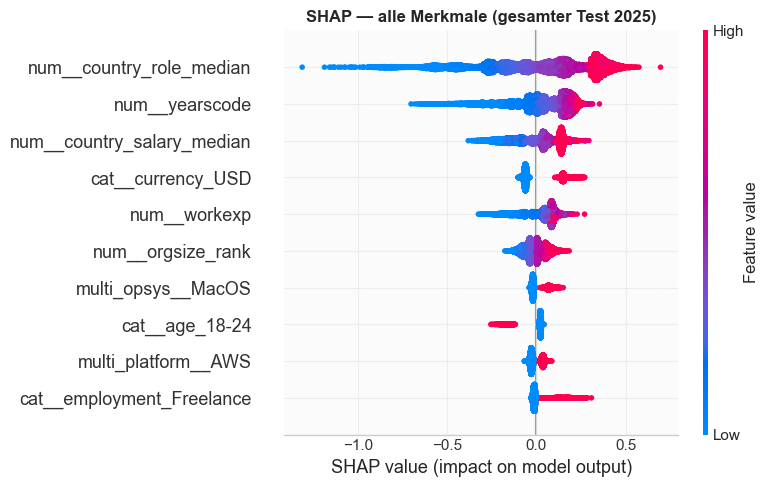

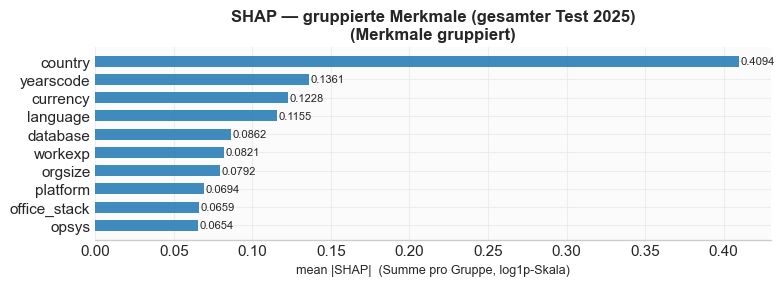

In [38]:
# Generierung der Modellvorhersagen für den gesamten Testdatensatz
target_pred_all = best_model.predict(features_test)

# Visualisierung der globalen Merkmalsbedeutung mittels Beeswarm-Plot
# Darstellung der Top-10 Merkmale zur Identifikation der Haupteinflussfaktoren
plot_shap_global(shap_vals, X_test_transformed, feat_names, title="SHAP — alle Merkmale (gesamter Test 2025)", max_display=10)

# Aggregation und Darstellung der gruppierten Merkmalsbedeutungen
# Analyse des Einflusses von Merkmalsgruppen (z. B. Tech-Stacks) auf das Gehalt
plot_shap_grouped(shap_df, feat_names, title="SHAP — gruppierte Merkmale (gesamter Test 2025)", max_display=10)

📈 Gehaltseinfluss-Analyse nach Skills

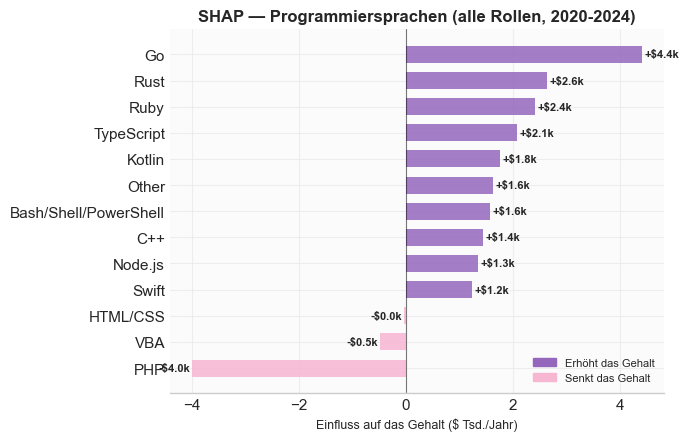

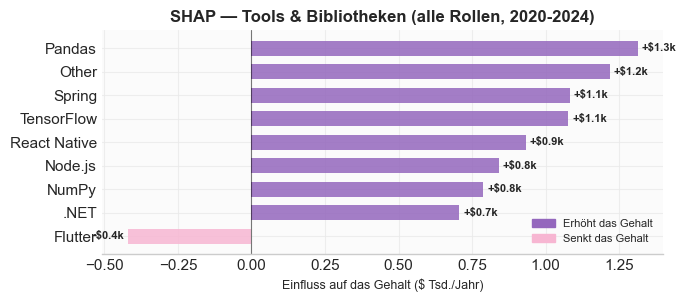

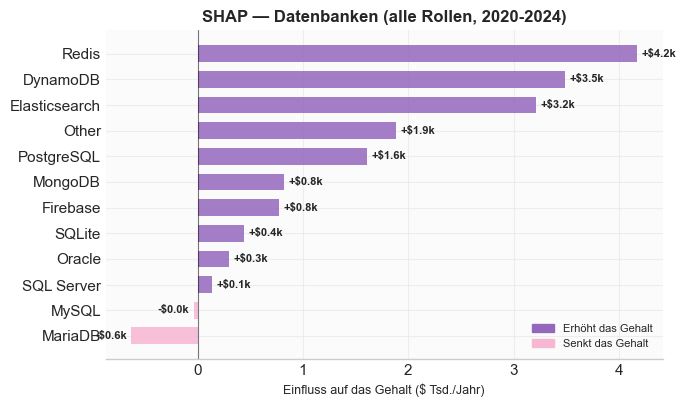

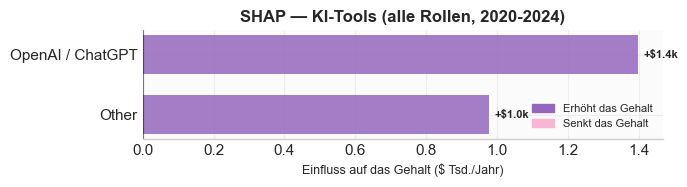

In [40]:
# Detaillierte Analyse und Visualisierung der finanziellen Auswirkungen spezifischer IT-Skills
# Untersuchung der Stichprobe (2020-2024) zur Identifikation von Gehaltstreibern
plot_shap_multi_cols(shap_df_sample, skill_meta, median_salary_global, source_features=source_sample, title_suffix=' (alle Rollen, 2020-2024)', 
                     multi_cols_to_show=['language', 'tech', 'database', 'ai'], min_rows=10, max_per_col=20)

🔹 Validierung der Skill-Abdeckung und Datenqualität

In [863]:
# # Diagnose der Skill-Abdeckung innerhalb des shap_df_pure DataFrames
# # Extraktion relevanter Merkmale mit dem Präfix 'multi_' für die Analyse
# print("\nSkill-Abdeckung in shap_df_pure:")
# multi_feats = [f for f, m in skill_meta.items() if m["level"].startswith("multi_") and f in shap_df_pure.columns]

# coverage = {}
# for f in multi_feats:
#     if f not in shap_df_pure.columns:
#         continue

#     # Bestimmung des Spaltennamens und Prüfung der Skill-Präsenz in den Quelldaten
#     prefix, skill_name = (f.split("__", 1) if "__" in f else (f, f))
#     col_name = prefix.replace("multi_", "")
#     if col_name in source_pure.columns:
#         n_with_skill = source_pure[col_name].str.contains(
#             skill_name, regex=False, na=False).sum()
#     else:
#         n_with_skill = len(shap_df_pure)

#     n_total  = len(shap_df_pure)
#     usd      = shap_log_to_usd_skill(f, shap_df_pure, median_salary_global, source_features=source_pure, min_rows=0)

#     # Berechnung des mittleren SHAP-Wertes zur Bewertung des Einflusses
#     if col_name in source_pure.columns:
#         has_skill = source_pure[col_name].str.contains(skill_name, regex=False, na=False)
#         idx       = shap_df_pure.index.intersection(source_pure[has_skill].index)
#         mean_shap = shap_df_pure.loc[idx, f].mean() if len(idx) > 0 else 0.0
#     else:
#         mean_shap = shap_df_pure[f].mean()

#     # Zusammenführung der Diagnosedaten in ein Dictionary
#     coverage[skill_meta[f]["skill"]] = {"n_with_skill": n_with_skill, "pct": round(n_with_skill / n_total * 100, 1), "mean_shap": round(mean_shap, 4), "usd_k":  round(usd, 2)}

# # Aufbereitung und Sortierung der Ergebnisse zur tabellarischen Darstellung
# coverage_df = (pd.DataFrame(coverage).T.sort_values("n_with_skill", ascending=False))

# # Ausgabe der statistischen Zusammenfassung zur Qualitätskontrolle
# print(coverage_df.head(30).to_string())
# print(f"\nSkills mit usd > 0: {(coverage_df['usd_k'] > 0).sum()}")
# print(f"Skills mit usd < 0: {(coverage_df['usd_k'] < 0).sum()}")
# print(f"Skills mit n < 10: {(coverage_df['n_with_skill'] < 10).sum()}")
# print(f"Skills mit n = 0: {(coverage_df['n_with_skill'] == 0).sum()}")

---
## 💼 7. IT & Data Career Advisor — Empfehlungssystem

🚗 Initialisierung des DataCareerAdvisor

In [74]:
# Definition der Analysebasis für den DataCareerAdvisor
# Auswahl der SHAP-Werte und Quelldaten (Stichprobe bei Verfügbarkeit, sonst Gesamtdaten)
_shap_df = shap_df_sample if "shap_df_sample" in dir() else shap_df
_source  = source_sample if "source_sample" in dir() else source_all

# Instanziierung des CareerAdvisor zur Modellberatung
# Übergabe der Pipeline, Metadaten und statistischen Referenzwerte
advisor = DataCareerAdvisor(df = df,
                            skill_meta = skill_meta, 
                            pipeline = best_model,
                            shap_df = _shap_df,
                            median_salary_global = median_salary_global,
                            num_cols = num_cols, 
                            cat_cols = cat_cols,
                            source_features = _source)

# Bestätigung der erfolgreichen Initialisierung
print("✔️ CareerAdvisor initialisiert")

✔️ CareerAdvisor initialisiert


🔅 Advisor-Parameter

In [76]:
# # Abruf der verfügbaren Filterkriterien und Parameter des DataCareerAdvisor
advisor.available_roles()
# advisor.available_countries()
# advisor.available_education()
# advisor.available_remote()
# advisor.available_org_sizes()
# advisor.available_industries()
# advisor.available_icorpm()
# advisor.available_skills()

Verfügbare Rollen (in profile['role'] eingeben):

  ── Developer Software Engineering ──
    Developer, back-end  (145,850)
  ── Developer Platform & Infrastructure ──
    Architect, software or solutions  (3,307)
  ── Developer Hardware & Systems ──
    Hardware Engineer  (4,439)
  ── Developer Community & Specialized ──
    Blockchain  (414)
  ── DevOps & SRE ──
    Engineer, site reliability  (6,765)
  ── Management ──
    Founder, technology or otherwise  (6,051)
  ── Research ──
    Applied scientist  (6,037)
  ── Security ──
    Security professional  (553)
  ── Designer ──
    UX, Research Ops or UI design professional  (1,834)
  ── Student ──
    Student  (494)
  ── Other ──
    Retired  (5,541)



🧩 Beispiele

1️⃣ Junior Data Specialist in Deutschland

In [51]:
# Definition des Nutzerprofils für die Gehalts- und Karriereanalyse
# Konfiguration der Parameter für einen Junior-Spezialisten (Data Scientist/ML) in Deutschland
profile_1 = {"role":  "Data scientist or machine learning specialist",
              "skills": ["Python", "SQL", "Pandas", "MySQL", "NumPy"],
              "years_experience": 2, 
              "country": "Germany", 
              "education": "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
              "remote": "Hybrid"}

# Generierung des umfassenden Karriere-Reports basierend auf dem Nutzerprofil
advisor.full_report(profile_1)

# Alternative Durchführung einer detaillierten Diagnose des Profils
# advisor.diagnose(profile_1)

——————————————————————————————————————————————————————————————
  📊 IT & Data Career Advisor — GEHALTSREPORT
——————————————————————————————————————————————————————————————
  Rolle:        Data Scientist / ML specialist  [Data Scientist / ML specialist]
  Seniorität:   Junior  (2 Jahre Erfahrung)
  Skills:       Python, SQL, Pandas, MySQL, NumPy
  Alter:        —
  Land:         Germany
  Abschluss:    Master's degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Hybrid

  💰 Erwartetes Gehalt:  $63,719 / Jahr
  📍 Marktmedian (Germany, Data Scientist / ML specialist):  $74,651 / Jahr

  💡 Top-5 Skills zum Erlernen:
     Redis                     +$   4,604/Jahr   [database]
     PostgreSQL                +$   1,694/Jahr   [database]
     OpenAI / ChatGPT          +$   1,451/Jahr   [ai]
     TensorFlow                +$   1,088/Jahr   [tech]
     MongoDB                   +$     796/Jahr   [database]
——————————————————————————————————————————————————————————————


2️⃣ Senior Data Scientist in den USA

In [52]:
profile_2 = {"role": "Data scientist or machine learning specialist",
             "skills": ["Python", "SQL", "PyTorch", "TensorFlow", "AWS", "Docker", "Kubernetes", "Spark", "Airflow", "OpenAI / ChatGPT"],
             "years_experience": 10,
             "country": "United States",
             "education": "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
             "remote": "Remote",
             "icorpm": "IC",
             "orgsize": "Large 1 (1-5k)"}

advisor.full_report(profile_2)
# advisor.diagnose(profile_2)

——————————————————————————————————————————————————————————————
  📊 IT & Data Career Advisor — GEHALTSREPORT
——————————————————————————————————————————————————————————————
  Rolle:        Data Scientist / ML specialist  [Data Scientist / ML specialist]
  Seniorität:   Senior  (10 Jahre Erfahrung)
  Skills:       Python, SQL, PyTorch, TensorFlow, AWS, Docker, Kubernetes, Spark, Airflow, OpenAI / ChatGPT
  Alter:        —
  Land:         United States
  Abschluss:    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Remote

  💰 Erwartetes Gehalt:  $137,439 / Jahr
  📍 Marktmedian (United States, Data Scientist / ML specialist):  $140,000 / Jahr

  💡 Top-5 Skills zum Erlernen:
     Redis                     +$   7,717/Jahr   [database]
     PostgreSQL                +$   2,294/Jahr   [database]
     Pandas                    +$   1,662/Jahr   [tech]
     MongoDB                   +$     619/Jahr   [database]
     NumPy                     +$     553/Jahr   [tech]
—————————————

3️⃣ Developer in Germany, mid-level

In [81]:
profile_3 = {"role": "Developer Software Engineering",
             "skills": ["JavaScript", "TypeScript", "React", "Node.js", "Python", "PostgreSQL", "Docker", "AWS", "GitHub Copilot"],
             "years_experience": 5,
             "country": "Germany",
             "education": "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)",
             "remote": "Hybrid",
             "orgsize": "Medium 1 (100-499)", 
             "icorpm": "IC",
             "age": "25-34 years old"}

advisor.full_report(profile_3)
# advisor.diagnose(profile_3)

——————————————————————————————————————————————————————————————
  📊 IT & Data Career Advisor — GEHALTSREPORT
——————————————————————————————————————————————————————————————
  Rolle:        Developer Software Engineering  [Other]
  Seniorität:   Mid  (5 Jahre Erfahrung)
  Skills:       JavaScript, TypeScript, React, Node.js, Python, PostgreSQL, Docker, AWS, GitHub Copilot
  Alter:        25-34 years old
  Land:         Germany
  Abschluss:    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Hybrid

  💰 Erwartetes Gehalt:  $70,179 / Jahr
  📍 Marktmedian (Germany, Developer Software Engineering):  $69,318 / Jahr

  💡 Top-5 Skills zum Erlernen:
     Redis                     +$   4,350/Jahr   [database]
     DynamoDB                  +$   3,625/Jahr   [database]
     Elasticsearch             +$   3,335/Jahr   [database]
     Rust                      +$   2,739/Jahr   [language]
     Bash/Shell/PowerShell     +$   1,605/Jahr   [language]
——————————————————————————————————————

4️⃣ Junior Data Scientist in der Ukraine, remote

In [54]:
profile_4 = {"role": "Data/Financial Analyst",
             "skills":  ["Python", "SQL", "Pandas", "NumPy", "Scikit-Learn", "TensorFlow", "PostgreSQL"],
             "years_experience": 2,
             "country": "Ukraine", 
             "education": "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
             "remote": "Remote",
             "orgsize": "Small (20-99)",
             "age": "25-34 years old"}

advisor.full_report(profile_4)
# advisor.diagnose(profile_4)

——————————————————————————————————————————————————————————————
  📊 IT & Data Career Advisor — GEHALTSREPORT
——————————————————————————————————————————————————————————————
  Rolle:        Data/Financial Analyst  [Other]
  Seniorität:   Junior  (2 Jahre Erfahrung)
  Skills:       Python, SQL, Pandas, NumPy, Scikit-Learn, TensorFlow, PostgreSQL
  Alter:        25-34 years old
  Land:         Ukraine
  Abschluss:    Master's degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Remote

  💰 Erwartetes Gehalt:  $19,242 / Jahr
  📍 Marktmedian (Ukraine, Data/Financial Analyst):  $23,983 / Jahr

  💡 Top-5 Skills zum Erlernen:
     Redis                     +$   2,190/Jahr   [database]
     DynamoDB                  +$   1,933/Jahr   [database]
     Elasticsearch             +$   1,830/Jahr   [database]
     Rust                      +$   1,618/Jahr   [language]
     Bash/Shell/PowerShell     +$   1,215/Jahr   [language]
——————————————————————————————————————————————————————————————


5️⃣ Senior Data Engineer aus United Kingdom

In [55]:
profile_5 = {"role": "DevOps engineer or professional",
             "skills": ["Python", "Bash/Shell/PowerShell", "Docker", "Kubernetes", "Terraform", "AWS", "GitHub Copilot"],
             "years_experience": 15,
             "country": "United Kingdom",
             "education": "Bachelor's degree (B.A., B.S., B.Eng., etc.)",
             "remote": "Hybrid",
             "orgsize": "Large 1 (1-5k)",
             "industry": "Finance",
             "icorpm": "IC",
             "age": "35-44 years old"}

advisor.full_report(profile_5)
# advisor.diagnose(profile_5)

——————————————————————————————————————————————————————————————
  📊 IT & Data Career Advisor — GEHALTSREPORT
——————————————————————————————————————————————————————————————
  Rolle:        DevOps & SRE  [DevOps & SRE]
  Seniorität:   Senior+  (15 Jahre Erfahrung)
  Skills:       Python, Bash/Shell/PowerShell, Docker, Kubernetes, Terraform, AWS, GitHub Copilot
  Alter:        35-44 years old
  Land:         United Kingdom
  Abschluss:    Bachelor's degree (B.A., B.S., B.Eng., etc.)
  Arbeitsform:  Hybrid

  💰 Erwartetes Gehalt:  $94,376 / Jahr
  📍 Marktmedian (United Kingdom, DevOps & SRE):  $77,556 / Jahr

  💡 Top-5 Skills zum Erlernen:
     Redis                     +$   4,742/Jahr   [database]
     DynamoDB                  +$   3,933/Jahr   [database]
     Elasticsearch             +$   3,609/Jahr   [database]
     Rust                      +$   2,943/Jahr   [language]
     PostgreSQL                +$   1,721/Jahr   [database]
—————————————————————————————————————————————————————————

---
## 📝 8. Fazit

✅ Ergebnisse

| Kennzahl | Wert |
| :--- | :--- |
| Bestes Modell | CatBoost + Optuna |
| MAE | $25,354k / Jahr |
| R² | 0.617 |
| Trainingsdaten | 176,834 Zeilen (2020–2024) |
| Testdaten | 21,794 Zeilen (2025) |